# Every WCCI evaluation, as a matrix report

This notebook reads **every result JSON under
`outputs/full_test_eval/shared/wcci`** and lays the whole corpus out as a small
family of matrices. It is a reference sheet, not an argument: the aim is that
any single evaluation in that directory can be located on one of these pages,
next to the evaluations it is comparable with.

The layout is the one from §13 of `transfer_story.ipynb`, reused unchanged for
every arm so the pages can be read against each other:

| element | what it shows |
|---|---|
| **left row strip** | the architecture, coloured by input condition (`NL` raw / `NLS` physically scaled) |
| **heat map(s)** | one panel per gate condition, architecture (row) x reduced action space (column) |
| **bars on top** | the column marginal, with the number of cells behind it |
| **bars on the right** | the *matched* difference between the two panels, cell by cell |
| **dashed line** | the do-nothing floor on the same metric |

### The one rule this report is built around

The corpus is **unbalanced by design** — experiments followed leads, so most
arms exist at one cap for a handful of architectures. A `mean` or a `max` taken
across arms therefore measures how many attempts an arm was given, not how good
it is. So:

* marginals are drawn **inside** one arm and one gate condition, never across
  arms;
* every marginal carries its **cell count**, and a bar backed by fewer cells
  than the panel has rows is **hatched**;
* every cross-arm number in this notebook is a **matched pair** on
  `(architecture, cap, gate)` via `wcci_transfer_data.matched_pairs()`, with a
  percentile bootstrap interval over the matched cells.

### Metric

Every matrix is on **survival on the difficult chronics** (`hard_pct`) — the
episodes do-nothing does not already survive — except §3, which rescales that
same number by the headroom available at each cap. Overall survival over all 50
chronics is dominated by the 26 episodes do-nothing already wins and is not
plotted anywhere; it is carried in `all_runs.csv` for reference.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
runs = data.runs.copy()
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy
EXPORT_DIR = data.export_dir / "wcci_full_matrix_report"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FAMILY_COLORS = {"NL": W.SCALING_COLORS["raw inputs"],
                 "NLS": W.SCALING_COLORS["physical scaling"]}
GATE_COLORS = dict(W.GATE_COLORS)


def save_figure(fig, stem):
    fig.savefig(EXPORT_DIR / f"{stem}.png", dpi=170, bbox_inches="tight")


# --- the one derived column ------------------------------------------------
# `load()` classifies by adaptation route. `cas_hl_gmax_delta_*` is the same
# route (zero-shot, no target-grid gradient) on a *different backbone*:
# `gnn_readout_aggr = "energized_max"` with the candidate-action delta encoder
# on, from configs/no_leakage_config/F_nl_cas_hl_max_arch. Leaving it inside
# the zero-shot route turns that route's 16 x 6 factorial into a 31-row block
# with two different networks stacked in the same cells.
GMAX_PREFIX = "cas_hl_gmax_delta"
runs["arm"] = np.where(
    runs["group"].str.startswith(GMAX_PREFIX),
    "bus14 zero-shot (gmax-delta)",
    runs["route"].astype(str),
)
ARM_ORDER = [
    "bus14 zero-shot",
    "bus14 zero-shot (gmax-delta)",
    "bus14 zero-shot + AIB",
    "MAPPO fine-tune (conservative)",
    "MAPPO fine-tune (aggressive)",
    "BC on greedy labels",
    "MAPPO scratch",
]
ARM_COLORS = {**W.ROUTE_COLORS, "bus14 zero-shot (gmax-delta)": "#8C6BB1"}
runs["arm"] = pd.Categorical(runs["arm"], categories=ARM_ORDER, ordered=True)
runs["mk_int"] = runs["mk"].astype("Int64")
runs["scored"] = runs["hard_pct"].notna()

display(Markdown(
    f"**{len(runs)} comparable evaluations** on `{W.TARGET_ENV}` x {W.N_EPISODES} episodes, "
    f"in {runs['arm'].nunique()} arms and {runs['variant'].nunique()} architectures.  \n"
    f"**{int(runs['scored'].sum())}** carry the per-episode artifact needed for the "
    f"difficult-cohort split; the other **{int((~runs['scored']).sum())}** can only be "
    f"placed on overall survival.  \n"
    f"Floors: do-nothing scores **{DN_HARD:.2f}%** on the {N_HARD} difficult chronics and "
    f"**{DN_OVERALL:.2f}%** over all {W.N_EPISODES}."
))

**497 comparable evaluations** on `bus36_wcci_nomaint` x 50 episodes, in 7 arms and 16 architectures.  
**496** carry the per-episode artifact needed for the difficult-cohort split; the other **1** can only be placed on overall survival.  
Floors: do-nothing scores **8.34%** on the 24 difficult chronics and **56.00%** over all 50.

In [2]:
# ---------------------------------------------------------------------------
# The shared matrix template. Every figure in this notebook is one call to it,
# so the pages can be read against each other without re-learning a layout.
# ---------------------------------------------------------------------------
def matrix_panel(
    panels,                 # {panel title: DataFrame(index=row, columns=column)}
    *,
    title,
    metric_label,
    floor=None,             # horizontal reference drawn on the marginal bars
    floor_label=None,       # what that reference means, for the legend
    stem=None,
    cmap="YlGnBu",
    vmin=0.0,
    vmax=None,
    delta=None,             # Series indexed like the rows, drawn on the right
    delta_label=None,
    delta_note=None,
    column_label="Reduced action space",
    column_fmt="mk{}",
    marginal="mean",        # "mean" | "count" | None
    matched_marginal=True,  # marginal over rows present in *every* panel
    panel_colors=None,
    row_labels=None,
    row_colors=None,
    fmt=".1f",
    row_height=0.34,
    col_width=0.90,
):
    """Row strip + N heat maps + column marginals + a matched delta bar.

    `marginal="mean"` with `matched_marginal` restricts each column's mean to
    the rows evaluated in *every* panel of the figure, so bars across panels are
    a paired comparison rather than two different subsets; a bar resting on
    fewer rows than the panel holds is hatched, and every bar carries its cell
    count. `marginal="count"` replaces the means with those counts outright —
    the honest choice when the columns are different arms, where a mean would
    report how many attempts each arm was given rather than how good it is.
    """
    names = list(panels)
    order = list(next(iter(panels.values())).index)
    columns = list(next(iter(panels.values())).columns)
    panels = {name: frame.reindex(index=order, columns=columns) for name, frame in panels.items()}
    if vmax is None:
        vmax = max(float(np.nanmax([np.nanmax(f.to_numpy(dtype=float)) for f in panels.values()])),
                   1e-9)

    # Rows scored in every panel: the basis for a marginal that is comparable
    # across panels. With a single panel this is simply "the rows with data".
    common = pd.DataFrame(
        np.logical_and.reduce([panels[n].notna().to_numpy() for n in names]),
        index=order, columns=columns,
    )
    bases = {n: (panels[n].where(common) if matched_marginal else panels[n]) for n in names}
    means = {n: bases[n].mean() for n in names}
    counts = {n: bases[n].notna().sum() for n in names}
    heights = counts if marginal == "count" else means
    stacked = pd.concat(list(heights.values())).dropna() if marginal else pd.Series(dtype=float)
    low = min(0.0, float(stacked.min()) * 1.20) if len(stacked) else 0.0
    high = max(float(stacked.max()) * 1.20 if len(stacked) else 1.0, (floor or 0.0) * 1.20, 1e-9)

    # Geometry in inches, so the row strip is sized by its longest label instead
    # of by a ratio that silently clips it, and so the margins actually reserve
    # room for the tick labels, the panel titles and the legend below them.
    labels = {row: (row_labels or {}).get(row, str(row)) for row in order}
    tick_text = [column_fmt.format(c) for c in columns]
    tick_lines = max(len(text.split("\n")) for text in tick_text)
    tick_chars = max(len(line) for text in tick_text for line in text.split("\n"))
    rotation = 90 if tick_chars > 7 else 0

    strip_w = 0.062 * max(len(text) for text in labels.values()) + 0.28
    panel_w = col_width * max(len(columns), 1.6)
    delta_w = 1.65 if delta is not None else 0.0
    top_h = 0.95 if marginal else 0.0
    grid_h = row_height * len(order)
    top_margin = 0.48 if marginal else 0.14
    bottom_margin = 0.66 + (0.070 * tick_chars if rotation else 0.17 * tick_lines)
    fig_w = strip_w + panel_w * len(names) + delta_w + 0.85
    fig_h = grid_h + top_h + top_margin + bottom_margin

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        2, 1 + len(names) + (1 if delta is not None else 0),
        width_ratios=[strip_w] + [panel_w] * len(names) + ([delta_w] if delta is not None else []),
        height_ratios=[max(top_h, 1e-3), grid_h],
        wspace=0.06, hspace=0.08, left=0.58 / fig_w, right=0.995,
        top=1 - top_margin / fig_h, bottom=bottom_margin / fig_h,
    )

    ax_strip = fig.add_subplot(gs[1, 0])
    for y, row in enumerate(order):
        if row_colors and row in row_colors:
            colour = row_colors[row]
        else:
            key = "NLS" if str(row).startswith("NLS") else (
                "NL" if str(row).startswith("NL") else None)
            colour = FAMILY_COLORS.get(key, "#9E9E9E")
        ax_strip.add_patch(plt.Rectangle((0, y), 1, 1, color=colour))
        ax_strip.text(0.5, y + 0.5, labels[row], ha="center", va="center",
                      fontsize=7.4, color="white")
    ax_strip.set(xlim=(0, 1), ylim=(len(order), 0), xticks=[], yticks=[])
    ax_strip.grid(False)
    for spine in ax_strip.spines.values():
        spine.set_visible(False)

    for index, name in enumerate(names):
        ax_main = fig.add_subplot(gs[1, index + 1])
        sns.heatmap(panels[name], annot=True, fmt=fmt, cmap=cmap, linewidths=0.7,
                    linecolor="white", cbar=False, ax=ax_main, vmin=vmin, vmax=vmax,
                    annot_kws={"fontsize": 7.6})
        ax_main.set(xlabel=column_label if index == 0 else "", ylabel="")
        ax_main.set_xticklabels(tick_text, fontsize=8.2, rotation=rotation, ha="center")
        ax_main.set_yticklabels([])
        ax_main.tick_params(left=False)

        if not marginal:
            continue
        ax_top = fig.add_subplot(gs[0, index + 1])
        colour = (panel_colors or {}).get(name, GATE_COLORS.get(name, "#9EC5E8"))
        bars = ax_top.bar(np.arange(len(columns)) + 0.5, heights[name].fillna(0), width=0.74,
                          color=colour, edgecolor="white", linewidth=1.0)
        for bar, value, count in zip(bars, heights[name], counts[name]):
            centre = bar.get_x() + bar.get_width() / 2
            if marginal == "mean" and count < len(order):
                bar.set_hatch("///")
                bar.set_edgecolor("#555555")
            if value is None or (isinstance(value, float) and np.isnan(value)):
                ax_top.annotate("n/a", (centre, 0), xytext=(0, 4), textcoords="offset points",
                                ha="center", fontsize=7, color="#888888")
                continue
            text = f"{value:.0f}" if marginal == "count" else f"{value:.1f}\nn={int(count)}"
            ax_top.annotate(text, (centre, max(value, 0)), xytext=(0, 3),
                            textcoords="offset points", ha="center", va="bottom",
                            fontsize=7.2, linespacing=1.15)
        if floor is not None and marginal == "mean":
            ax_top.axhline(floor, color="black", linestyle="--", linewidth=1.2)
        ax_top.set(xlim=(0, len(columns)), xticks=[], ylim=(low, high))
        ax_top.set_title(name, fontsize=10.5, pad=6)
        if index:
            ax_top.set_yticklabels([])
        else:
            ax_top.set_ylabel("cells" if marginal == "count" else "column mean", fontsize=8)

    if delta is not None:
        ax_right = fig.add_subplot(gs[1, -1])
        values = pd.Series(delta).reindex(order)
        ax_right.barh(np.arange(len(order)) + 0.5, values.fillna(0),
                      color=["#2E7D32" if v > 0 else "#E45756" for v in values.fillna(0)],
                      edgecolor="white", linewidth=1.0, height=0.74)
        for y, value in enumerate(values):
            if np.isnan(value):
                ax_right.text(0, y + 0.5, " n/a", va="center", fontsize=6.4, color="#888888")
        ax_right.axvline(0, color="black", linewidth=1.2)
        ax_right.set(ylim=(len(order), 0), yticks=[])
        ax_right.set_xlabel(delta_label or "difference (pp)", fontsize=8.5)
        ax_right.tick_params(labelsize=7.5)

    handles = [Patch(color=colour, label=f"row strip — {W.SCALING_LABELS[key]}")
               for key, colour in FAMILY_COLORS.items()]
    if floor is not None and marginal == "mean":
        handles.append(Line2D([], [], color="black", linestyle="--",
                              label=floor_label or f"do nothing ({floor:.1f}%)"))
    if marginal == "mean":
        handles.append(Patch(facecolor="white", edgecolor="#555555", hatch="///",
                             label="marginal resting on fewer cells than the panel has rows"))
    elif marginal == "count":
        handles.append(Patch(facecolor="#B0BEC5",
                             label="top bars are cell counts, not means — these columns "
                                   "are different arms"))
    if delta_note:
        handles.append(Patch(facecolor="none", edgecolor="none", label=delta_note))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2,
               fontsize=8.2, frameon=False)
    fig.suptitle(f"{title}\n{metric_label}", y=1.0, va="bottom", fontsize=12.5)
    if stem:
        save_figure(fig, stem)
    plt.show()


def cell_matrix(frame, index, columns, value, aggfunc="mean"):
    """One evaluation per cell; `aggfunc` only ever fires where the corpus doubles up."""
    return frame.pivot_table(index=index, columns=columns, values=value,
                             aggfunc=aggfunc, observed=True)


def order_by_mean(*frames):
    """Row order shared by every panel of a figure: best mean first."""
    stacked = pd.concat(frames)
    return stacked.groupby(level=0).mean().mean(axis=1).sort_values(ascending=False).index.tolist()

## 1. What is actually in the directory

Before any matrix of results, a matrix of *existence*. The corpus is the union
of several campaigns run at different times, and the holes are the single most
important thing to know about it — they decide which comparisons are legal.

Two things the shared loader does not say on its own, and this report does:

1. `cas_hl_gmax_delta_*` is **not** part of the zero-shot factorial. Same
   route, different backbone (`energized_max` graph readout + candidate-action
   delta encoder). It is split out into its own arm here.
2. A run's per-episode artifact is not always where its own result JSON says it
   is. The path in the JSON is the sync root the *job* used; a later sync can
   put the same files under a different one. The loader falls back to matching
   on the `run / evaluation / filename` tail, accepts only an unambiguous match,
   and still checks that the CSV reproduces the survival in its own JSON — so a
   relocated artifact is verified, never assumed.

#### Every (arm, cap, gate) cell in the directory

,arm,mk_int,gate,evaluations,scored,architectures,selections,rho
0,bus14 zero-shot,32,gated,16,16,16,best test,0.95
1,bus14 zero-shot,32,ungated,16,16,16,best test,—
2,bus14 zero-shot,64,gated,17,17,8,best test,0.85/0.90/0.95/1.00
3,bus14 zero-shot,64,ungated,16,16,16,best test,—
4,bus14 zero-shot,128,gated,11,11,4,best test,0.85/0.90/0.95/1.00
5,bus14 zero-shot,128,ungated,16,16,16,best test,—
6,bus14 zero-shot,256,gated,10,10,4,best test,0.85/0.90/0.95/1.00
7,bus14 zero-shot,256,ungated,16,16,16,best test,—
8,bus14 zero-shot,512,ungated,16,16,16,best test,—
9,bus14 zero-shot,1024,ungated,16,16,16,best test,—


_64 artifacts were not at the path their own result JSON declares and were matched by their `run / evaluation / filename` tail instead (declared under: `corentinplumet` x64). Each one still had to reproduce the survival percentage in its own JSON to be used._

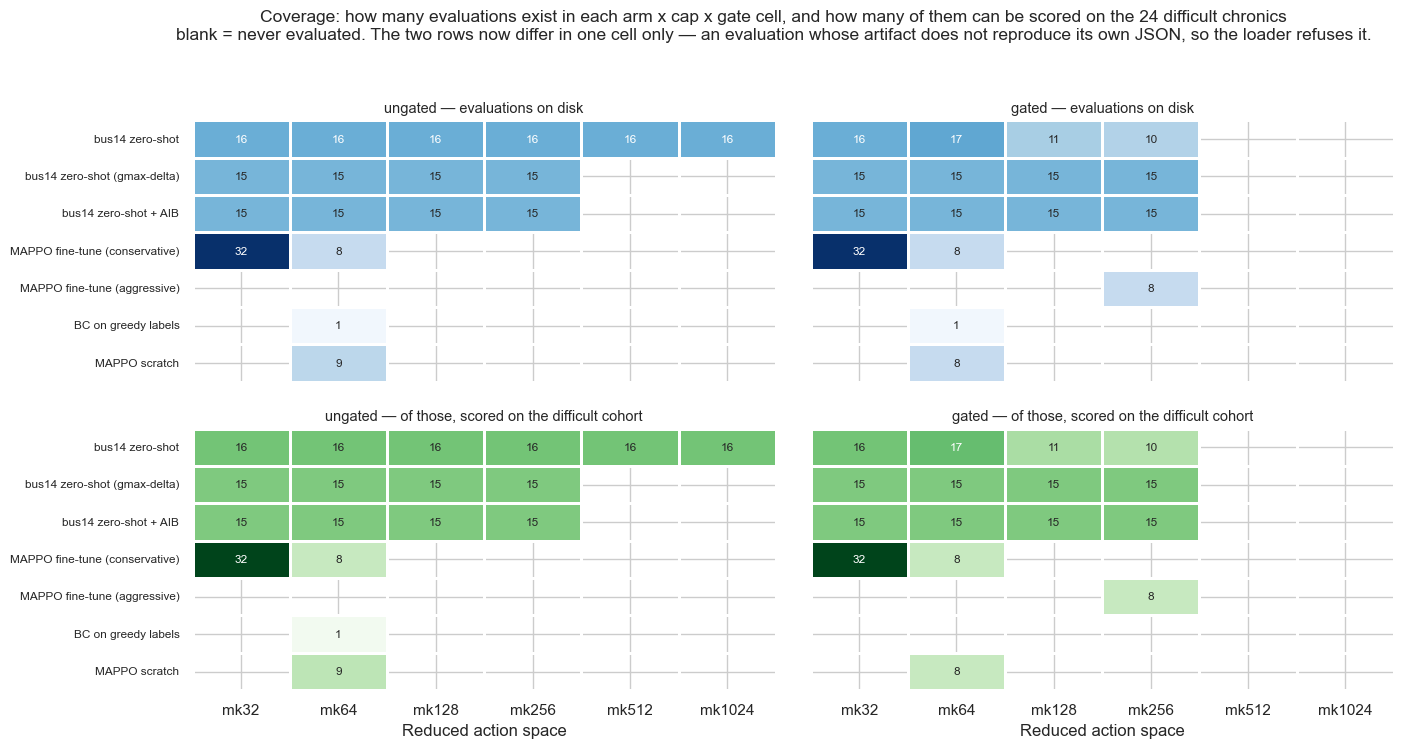

In [3]:
inventory = (
    runs.groupby(["arm", "mk_int", "gate"], observed=True)
    .agg(evaluations=("key", "size"),
         scored=("scored", "sum"),
         architectures=("variant", "nunique"),
         selections=("selection", lambda s: "/".join(sorted(set(s)))),
         rho=("rho", lambda s: "/".join(f"{v:.2f}" for v in sorted(set(s.dropna()))) or "—"))
    .reset_index()
)
inventory["scored"] = inventory["scored"].astype(int)
display(Markdown("#### Every (arm, cap, gate) cell in the directory"))
display(inventory)

if len(data.relocated_artifacts):
    roots = (
        data.relocated_artifacts["declared"].str.split("/").str[2].value_counts().to_dict()
    )
    display(Markdown(
        f"_{len(data.relocated_artifacts)} artifacts were not at the path their own result "
        f"JSON declares and were matched by their `run / evaluation / filename` tail instead "
        f"(declared under: {', '.join(f'`{k}` x{v}' for k, v in roots.items())}). "
        f"Each one still had to reproduce the survival percentage in its own JSON to be "
        f"used._"
    ))

count_panels = {
    gate: cell_matrix(runs.loc[runs["gate"] == gate], "arm", "mk_int", "key", "count")
          .reindex(index=[a for a in ARM_ORDER], columns=W.caps_in(runs))
    for gate in ("ungated", "gated")
}
scored_panels = {
    gate: cell_matrix(runs.loc[runs["gate"] == gate], "arm", "mk_int", "scored", "sum")
          .reindex(index=[a for a in ARM_ORDER], columns=W.caps_in(runs))
    for gate in ("ungated", "gated")
}

fig, axes = plt.subplots(2, 2, figsize=(15.5, 7.4), sharex=True,
                         gridspec_kw={"hspace": 0.18, "wspace": 0.06})
for row, (label, panels, cmap) in enumerate([
    ("evaluations on disk", count_panels, "Blues"),
    ("of those, scored on the difficult cohort", scored_panels, "Greens"),
]):
    for col, gate in enumerate(("ungated", "gated")):
        ax = axes[row, col]
        matrix = panels[gate].fillna(0)
        sns.heatmap(matrix, annot=True, fmt=".0f", cmap=cmap, linewidths=0.8,
                    linecolor="white", cbar=False, ax=ax, vmin=0,
                    mask=matrix.eq(0), annot_kws={"fontsize": 8.5})
        ax.set(xlabel="", ylabel="")
        ax.set_xticklabels([f"mk{c}" for c in matrix.columns])
        if col == 0:
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)
        else:
            ax.set_yticklabels([])
        ax.set_title(f"{gate} — {label}", fontsize=10.5)
axes[1, 0].set_xlabel("Reduced action space")
axes[1, 1].set_xlabel("Reduced action space")
unscored_cells = int((~runs["scored"]).sum())
fig.suptitle(
    "Coverage: how many evaluations exist in each arm x cap x gate cell, "
    "and how many of them can be scored on the 24 difficult chronics\n"
    "blank = never evaluated. The two rows now differ in "
    f"{'one cell only' if unscored_cells == 1 else f'{unscored_cells} cells'} — "
    "an evaluation whose artifact does not reproduce its own JSON, so the loader refuses it.",
    y=1.03, fontsize=12.5,
)
save_figure(fig, "01_coverage_matrix")
plt.show()

### What this says

Three blocks are complete rectangles and can carry their own marginals — and all
three are now fully scored on the difficult cohort:

* **zero-shot `cas_hl`, ungated** — 16 architectures x 6 caps;
* **gmax-delta**, both gates — 15 architectures x 4 caps;
* **AIB**, both gates — 15 architectures x 4 caps.

Everything else is a lead that was followed: the gated `cas_hl` screen covers a
handful of cells at 1–4 rho thresholds each, and each target-trained route
exists at one or two caps for a subset of the architectures. Those arms get
matrices too, but with their holes left visible and no marginals drawn across
them.

Only **one** evaluation in the whole directory cannot be placed on the difficult
cohort, and it is refused rather than missing: one `dangerous_graph_bc` run
whose episode CSV does not reproduce the survival percentage in its own JSON.
That is a real mis-attribution on disk, not a sync gap, so the loader drops it.

## 2. The balanced core — `cas_hl` zero-shot, 16 architectures x 4 caps

This is the block everything else is measured against: one evaluation per cell,
no target-grid gradient, no gate. The gated panel beside it is the **local-rho
0.95** screen, the one threshold applied broadly enough to be worth a panel —
and it is sparse, so its holes are left blank and its marginals are hatched
wherever they rest on fewer than 16 architectures.

`mk512` and `mk1024` were evaluated but are **not plotted**. Every architecture
collapses at those caps, no other arm reaches them, so the two columns add no
contrast and only stretch the colour scale. Their numbers are printed under the
figure and kept in `all_runs.csv`. Everything downstream — §3, and the factorial
in §7 — therefore runs on the same four caps as the other two complete blocks,
which is what makes the three comparable at all.

The right-hand bars are the matched gate effect: for each architecture, the mean
over caps of (gated − ungated) **taken only where both were evaluated**.

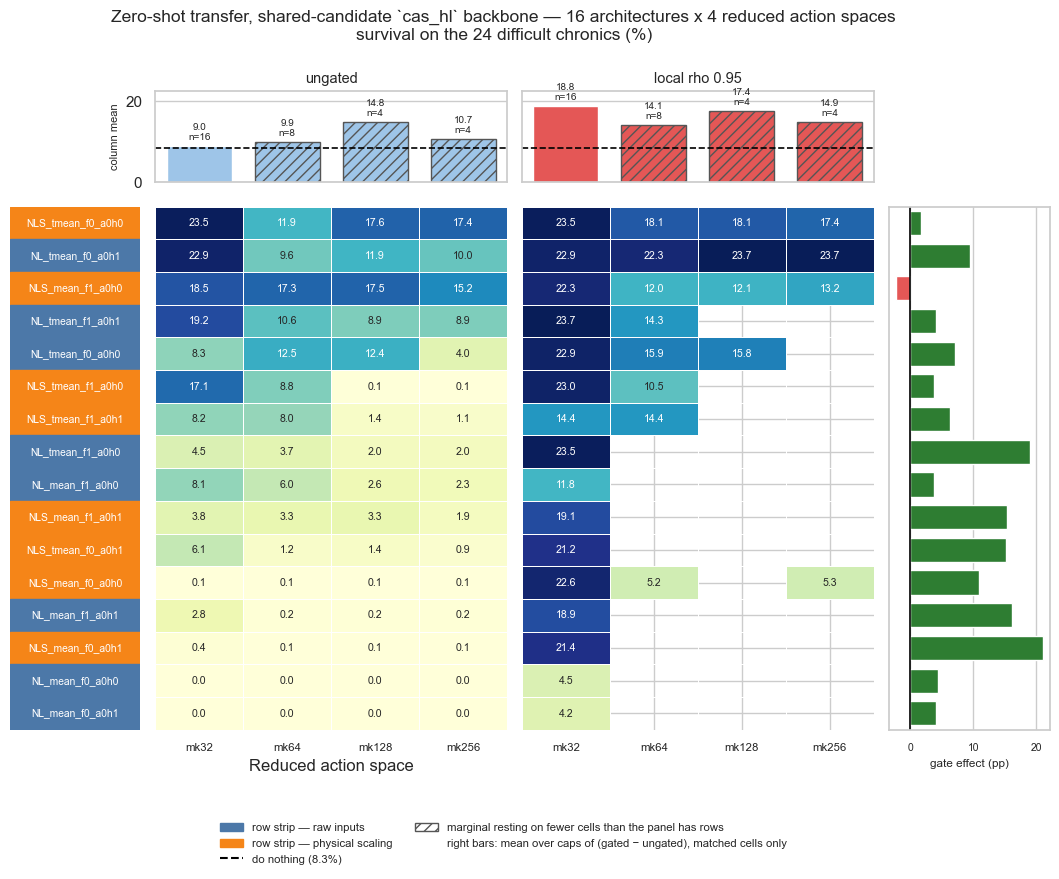

_**mk512**, **mk1024** are evaluated but not plotted: nothing survives there. Their ungated block means and best cells, against a do-nothing floor of 8.34%:_

,block_mean,best,architectures_above_floor
mk_int,,,
512,2.05,14.87,1
1024,0.45,1.20,0


#### Matched gate contrast — 32 cells where both conditions were evaluated

,contrast,cells,mean_pp,ci_low,ci_high,cells_improved,cells_worsened
0,local rho 0.95 − ungated,32,6.80,4.40,9.36,26,4


In [4]:
core = runs.loc[runs["arm"] == "bus14 zero-shot"].copy()
CORE_CAPS_EVALUATED = W.caps_in(core)
# mk512 and mk1024 are dropped from every matrix. Every architecture collapses
# there, no other arm was ever evaluated that high, and the two columns
# therefore carry no contrast — they only stretch the colour scale. The numbers
# stay in `all_runs.csv`, and the marginals they would have contributed are
# printed under the figure rather than silently discarded.
CORE_CAPS = [cap for cap in CORE_CAPS_EVALUATED if cap <= 256]
DROPPED_CAPS = [cap for cap in CORE_CAPS_EVALUATED if cap not in CORE_CAPS]
# One gate condition, one threshold: the loader keeps 0.85/0.90/0.95/1.00 and a
# `max` over them would silently be a per-cell threshold search.
core_gated = core.loc[(core["gate"] == "gated") & np.isclose(core["rho"], 0.95)
                      & core["mk"].isin(CORE_CAPS)]
core_ungated = core.loc[(core["gate"] == "ungated") & core["mk"].isin(CORE_CAPS)]

CORE_HARD = {
    "ungated": cell_matrix(core_ungated, "variant", "mk_int", "hard_pct"),
    "local rho 0.95": cell_matrix(core_gated, "variant", "mk_int", "hard_pct"),
}
CORE_ORDER = order_by_mean(*CORE_HARD.values())
CORE_HARD = {k: v.reindex(index=CORE_ORDER, columns=CORE_CAPS) for k, v in CORE_HARD.items()}

gate_pairs = W.matched_pairs(
    pd.concat([core_ungated, core_gated]), "gate", ("ungated", "gated"),
    ["variant", "mk"], value="hard_pct",
)
gate_effect = gate_pairs.groupby("variant")["delta"].mean()

matrix_panel(
    CORE_HARD,
    title=f"Zero-shot transfer, shared-candidate `cas_hl` backbone — "
          f"{len(CORE_ORDER)} architectures x {len(CORE_CAPS)} reduced action spaces",
    metric_label=f"survival on the {N_HARD} difficult chronics (%)",
    floor=DN_HARD,
    delta=gate_effect,
    delta_label="gate effect (pp)",
    delta_note="right bars: mean over caps of (gated − ungated), matched cells only",
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="02_core_zero_shot_hard",
)

if DROPPED_CAPS:
    dropped = (
        core.loc[(core["gate"] == "ungated") & core["mk"].isin(DROPPED_CAPS)]
        .groupby("mk_int", observed=True)["hard_pct"]
        .agg(block_mean="mean", best="max", architectures_above_floor=lambda v: int((v > DN_HARD).sum()))
    )
    display(Markdown(
        "_"
        + ", ".join(f"**mk{cap}**" for cap in DROPPED_CAPS)
        + " are evaluated but not plotted: nothing survives there. Their ungated block "
        "means and best cells, against a do-nothing floor of "
        f"{DN_HARD:.2f}%:_"
    ))
    display(dropped.round(2))

display(Markdown(
    f"#### Matched gate contrast — {len(gate_pairs)} cells where both conditions were evaluated"
))
mean_d, lo, hi = W.paired_bootstrap(gate_pairs["delta"])
display(pd.DataFrame([{
    "contrast": "local rho 0.95 − ungated",
    "cells": len(gate_pairs),
    "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
    "cells_improved": int((gate_pairs["delta"] > 0).sum()),
    "cells_worsened": int((gate_pairs["delta"] < 0).sum()),
}]))

## 3. The same grid against its ceiling

Raw survival percentages are not comparable across columns: a bigger action
space is a bigger opportunity, and the greedy one-step oracle scores very
differently at mk32 than at mk256. `capture_hard_pct` rescales each cell by the
headroom actually available in its own column —

$$\text{capture} = 100 \cdot \frac{\text{model} - \text{do nothing}}{\text{greedy at the same cap} - \text{do nothing}}$$

— so 100 means "took everything the matching greedy oracle took" and 0 means
"did no better than doing nothing". Negative means it did worse than nothing.

The greedy oracle here is an empirical one-step simulation over the same reduced
action set. It is the available benchmark, not a theoretical maximum over all
action sequences.

#### The ceiling each column is scaled by

,mk,greedy_overall_pct,greedy_hard_pct,greedy_hard_rescues,greedy_easy_kept,dn_hard_pct,dn_overall_pct
0,32,67.89,33.11,4,26,8.34,56.00
1,64,81.85,67.88,9,23,8.34,56.00
2,128,84.73,68.19,12,26,8.34,56.00
3,256,97.56,94.92,20,26,8.34,56.00
4,512,88.27,77.12,16,25,8.34,56.00
5,1024,95.28,90.16,19,26,8.34,56.00


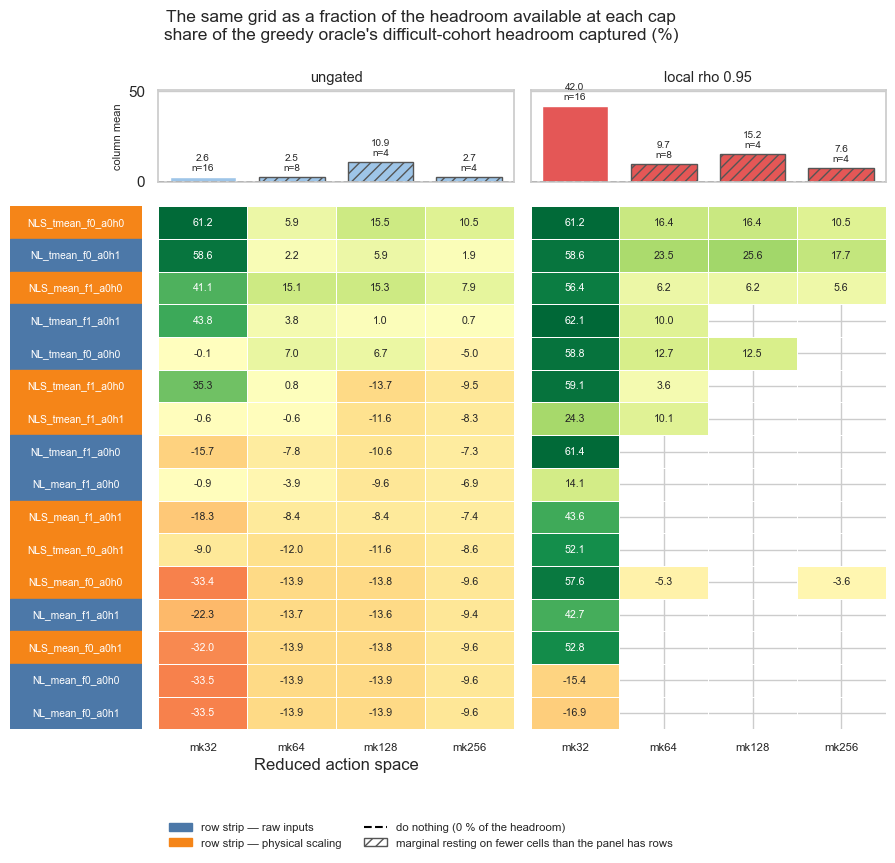

_Diverging scale, symmetric about 0. Green is headroom taken, red is worse than do-nothing; the dashed line on the marginals is the do-nothing floor, which on this metric sits at 0 by construction._

In [5]:
display(Markdown("#### The ceiling each column is scaled by"))
display(data.greedy_ceiling.assign(dn_hard_pct=DN_HARD, dn_overall_pct=DN_OVERALL))

CORE_CAPTURE = {
    "ungated": cell_matrix(core_ungated, "variant", "mk_int", "capture_hard_pct")
               .reindex(index=CORE_ORDER, columns=CORE_CAPS),
    "local rho 0.95": cell_matrix(core_gated, "variant", "mk_int", "capture_hard_pct")
                      .reindex(index=CORE_ORDER, columns=CORE_CAPS),
}
capture_span = float(np.nanmax([np.nanmax(f.to_numpy(dtype=float)) for f in CORE_CAPTURE.values()]))
matrix_panel(
    CORE_CAPTURE,
    title="The same grid as a fraction of the headroom available at each cap",
    metric_label="share of the greedy oracle's difficult-cohort headroom captured (%)",
    floor=0.0, floor_label="do nothing (0 % of the headroom)",
    cmap="RdYlGn",
    vmin=-capture_span, vmax=capture_span,
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="03_core_zero_shot_capture",
)
display(Markdown(
    "_Diverging scale, symmetric about 0. Green is headroom taken, red is worse than "
    "do-nothing; the dashed line on the marginals is the do-nothing floor, which on this "
    "metric sits at 0 by construction._"
))

## 4. The adaptive intervention budget — the second complete block

The AIB arm is the same shared-candidate actor trained on bus14 with the
**adaptive intervention budget** active (a Lagrangian on the local-safe cost,
targeting a 10 % intervention rate) and then transferred zero-shot exactly as
above. It is a different training recipe, so it is a separate arm and must not
be folded into §2's factorial — but it is itself a complete rectangle,
15 architectures x 4 caps x 2 gates, every cell scored, so it carries its own
marginals safely.

The question AIB was built to answer is on the right-hand bars of §2's figure:
the rho gate is a threshold hand-tuned at deployment, while AIB is a timing rule
learned during training and carried inside the weights. If AIB works, its
**ungated** panel should look like somebody else's **gated** panel.

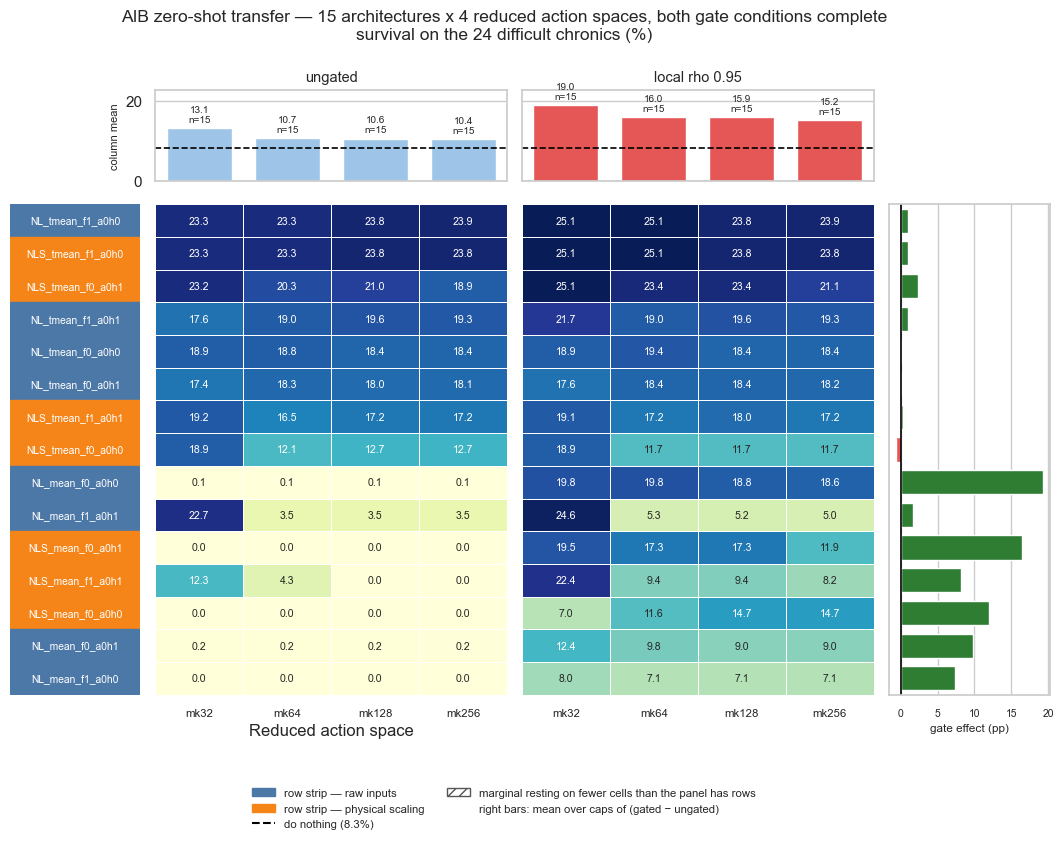

_15 of 16 architectures: `NLS_mean_f1_a0h0` has no AIB checkpoint._

In [6]:
aib = runs.loc[runs["arm"] == "bus14 zero-shot + AIB"].copy()
AIB_CAPS = W.caps_in(aib)
AIB_HARD = {gate: cell_matrix(aib.loc[aib["gate"] == gate], "variant", "mk_int", "hard_pct")
            for gate in ("ungated", "gated")}
AIB_ORDER = order_by_mean(*AIB_HARD.values())
AIB_HARD = {("local rho 0.95" if k == "gated" else k):
            v.reindex(index=AIB_ORDER, columns=AIB_CAPS) for k, v in AIB_HARD.items()}

aib_gate_pairs = W.matched_pairs(aib, "gate", ("ungated", "gated"), ["variant", "mk"],
                                 value="hard_pct")
matrix_panel(
    AIB_HARD,
    title=f"AIB zero-shot transfer — {len(AIB_ORDER)} architectures x {len(AIB_CAPS)} "
          f"reduced action spaces, both gate conditions complete",
    metric_label=f"survival on the {N_HARD} difficult chronics (%)",
    floor=DN_HARD,
    delta=aib_gate_pairs.groupby("variant")["delta"].mean(),
    delta_label="gate effect (pp)",
    delta_note="right bars: mean over caps of (gated − ungated)",
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="04_aib_matrix_hard",
)

missing_aib = sorted(set(CORE_ORDER) - set(AIB_ORDER))
if missing_aib:
    display(Markdown(
        f"_{len(AIB_ORDER)} of {len(CORE_ORDER)} architectures: "
        f"`{'`, `'.join(missing_aib)}` has no AIB checkpoint._"
    ))

### AIB against the plain zero-shot arm, cell by cell

Both arms exist at mk32/64/128/256 in both gate conditions, so this contrast can
be taken **inside** each `(architecture, cap, gate)` cell — no arm is being given
credit for having been run more often.

#### Paired contrasts, matched on architecture x cap

,contrast,condition,cells,mean_pp,ci_low,ci_high,cells_favouring_AIB
0,AIB − plain zero-shot,ungated,60,5.99,3.80,8.24,41
1,AIB − plain zero-shot,gated,28,0.65,-1.85,3.18,15
2,gate on bus14 zero-shot,ungated → local rho 0.95,32,6.80,4.40,9.36,26
3,gate on bus14 zero-shot + AIB,ungated → local rho 0.95,60,5.33,3.74,6.99,53


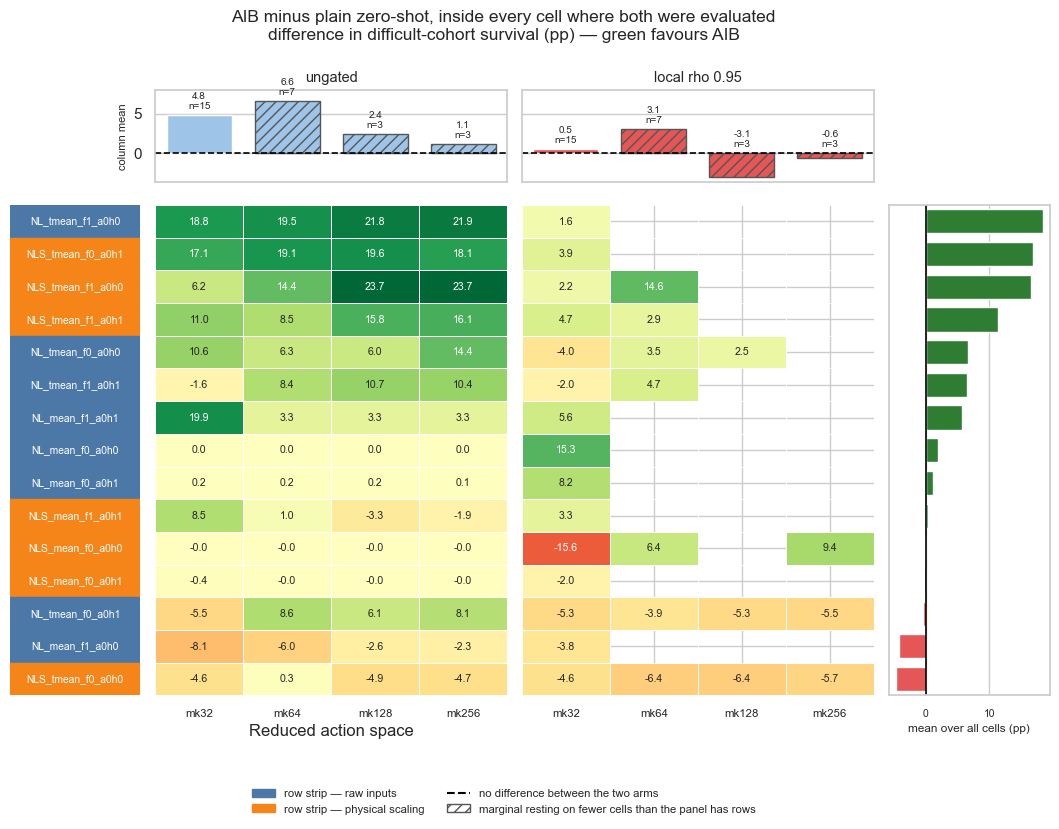

In [7]:
paired_arms = runs.loc[runs["arm"].isin(["bus14 zero-shot", "bus14 zero-shot + AIB"])
                       & runs["mk"].isin(AIB_CAPS)].copy()
# Keep the two arms on the same gate definition: one threshold, not a search.
paired_arms = paired_arms.loc[(paired_arms["gate"] == "ungated")
                              | np.isclose(paired_arms["rho"], 0.95)]

rows = []
for gate in ("ungated", "gated"):
    pairs = W.matched_pairs(paired_arms.loc[paired_arms["gate"] == gate], "arm",
                            ("bus14 zero-shot", "bus14 zero-shot + AIB"), ["variant", "mk"],
                            value="hard_pct")
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": "AIB − plain zero-shot", "condition": gate, "cells": len(pairs),
                 "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "cells_favouring_AIB": int((pairs["delta"] > 0).sum())})
for arm in ("bus14 zero-shot", "bus14 zero-shot + AIB"):
    subset = paired_arms.loc[paired_arms["arm"] == arm]
    pairs = W.matched_pairs(subset, "gate", ("ungated", "gated"), ["variant", "mk"],
                            value="hard_pct")
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": f"gate on {arm}", "condition": "ungated → local rho 0.95",
                 "cells": len(pairs), "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "cells_favouring_AIB": int((pairs["delta"] > 0).sum())})
aib_contrasts = pd.DataFrame(rows)
display(Markdown("#### Paired contrasts, matched on architecture x cap"))
display(aib_contrasts)

aib_delta_matrix = (
    W.matched_pairs(paired_arms.loc[paired_arms["gate"] == "ungated"], "arm",
                    ("bus14 zero-shot", "bus14 zero-shot + AIB"), ["variant", "mk"],
                    value="hard_pct")
    .pivot(index="variant", columns="mk", values="delta")
)
aib_delta_gated = (
    W.matched_pairs(paired_arms.loc[paired_arms["gate"] == "gated"], "arm",
                    ("bus14 zero-shot", "bus14 zero-shot + AIB"), ["variant", "mk"],
                    value="hard_pct")
    .pivot(index="variant", columns="mk", values="delta")
)
delta_order = order_by_mean(aib_delta_matrix, aib_delta_gated)
span = float(np.nanmax(np.abs(np.concatenate([
    aib_delta_matrix.to_numpy(dtype=float).ravel(),
    aib_delta_gated.to_numpy(dtype=float).ravel()]))))
matrix_panel(
    {"ungated": aib_delta_matrix.reindex(index=delta_order, columns=AIB_CAPS),
     "local rho 0.95": aib_delta_gated.reindex(index=delta_order, columns=AIB_CAPS)},
    title="AIB minus plain zero-shot, inside every cell where both were evaluated",
    metric_label="difference in difficult-cohort survival (pp) — green favours AIB",
    floor=0.0, floor_label="no difference between the two arms",
    cmap="RdYlGn", vmin=-span, vmax=span,
    delta=pd.concat([aib_delta_matrix, aib_delta_gated]).groupby(level=0).mean().mean(axis=1),
    delta_label="mean over all cells (pp)",
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="05_aib_minus_zero_shot",
)

## 5. The gmax-delta backbone — the third complete block

`cas_hl_gmax_delta_*` (config folder `F_nl_cas_hl_max_arch`) swaps the graph
readout to `energized_max` and turns on the candidate-action delta encoder,
keeping the same 2x2x2 shared-scorer factorial and the same 15M-step bus14
recipe. 120 evaluations, 15 architectures x 4 caps x 2 gates, complete — and
now fully scored, so it sits on the same difficult-cohort axis as §2 and §4.

Because the factorial and the training recipe are identical and only the
backbone differs, this is the cleanest architecture contrast in the corpus:
every gmax-delta cell has a `cas_hl` twin at the same architecture, cap and
gate.

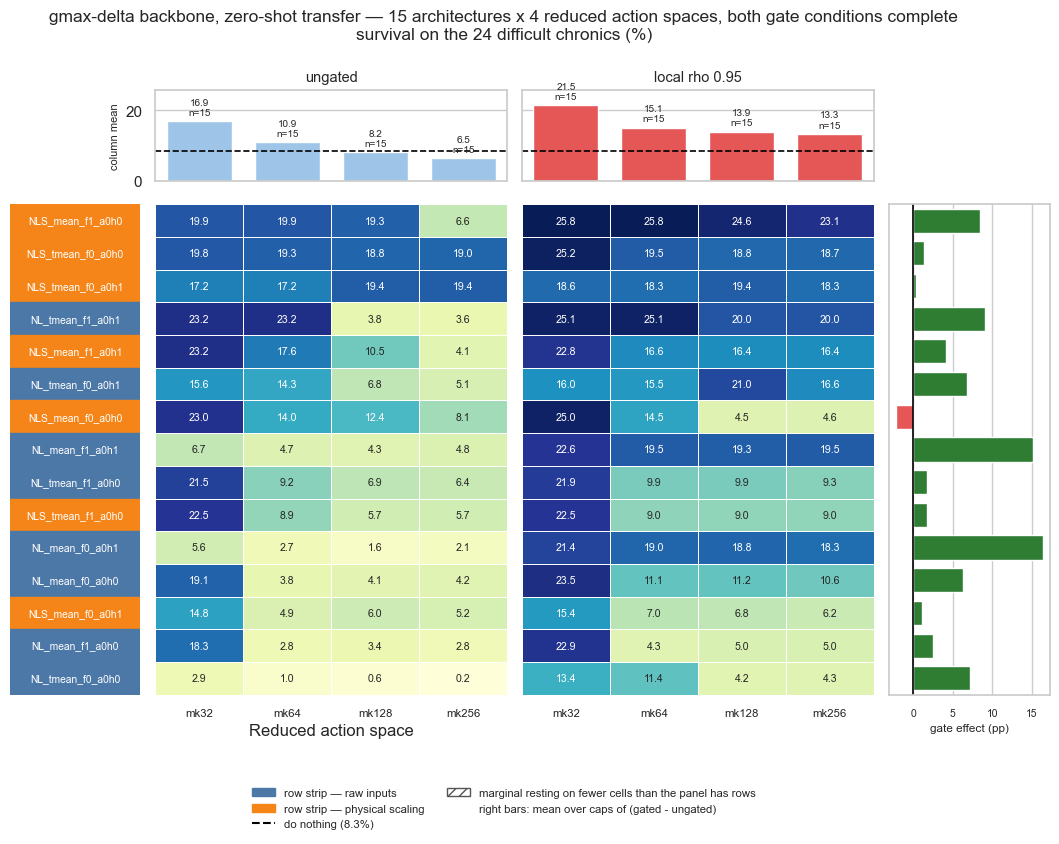

_15 of 16 architectures: `NLS_tmean_f1_a0h1` has no gmax-delta checkpoint._

In [8]:
gmax = runs.loc[runs["arm"] == "bus14 zero-shot (gmax-delta)"].copy()
GMAX_CAPS = W.caps_in(gmax)
GMAX_HARD = {gate: cell_matrix(gmax.loc[gmax["gate"] == gate], "variant", "mk_int", "hard_pct")
             for gate in ("ungated", "gated")}
GMAX_ORDER = order_by_mean(*GMAX_HARD.values())
GMAX_HARD = {("local rho 0.95" if k == "gated" else k):
             v.reindex(index=GMAX_ORDER, columns=GMAX_CAPS) for k, v in GMAX_HARD.items()}

gmax_gate_pairs = W.matched_pairs(gmax, "gate", ("ungated", "gated"), ["variant", "mk"],
                                  value="hard_pct")
matrix_panel(
    GMAX_HARD,
    title=f"gmax-delta backbone, zero-shot transfer — {len(GMAX_ORDER)} architectures x "
          f"{len(GMAX_CAPS)} reduced action spaces, both gate conditions complete",
    metric_label=f"survival on the {N_HARD} difficult chronics (%)",
    floor=DN_HARD,
    delta=gmax_gate_pairs.groupby("variant")["delta"].mean(),
    delta_label="gate effect (pp)",
    delta_note="right bars: mean over caps of (gated - ungated)",
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="06_gmax_matrix_hard",
)

missing_gmax = sorted(set(CORE_ORDER) - set(GMAX_ORDER))
if missing_gmax:
    display(Markdown(
        f"_{len(GMAX_ORDER)} of {len(CORE_ORDER)} architectures: "
        f"`{'`, `'.join(missing_gmax)}` has no gmax-delta checkpoint._"
    ))

### The backbone contrast, cell by cell

Same factorial, same recipe, same caps, same gate: the only thing that moves is
the graph readout and the delta encoder. Every difference below is taken inside
one `(architecture, cap, gate)` cell.

#### Paired contrasts, matched on architecture x cap

,contrast,condition,cells,mean_pp,ci_low,ci_high,cells_favouring_gmax
0,gmax-delta - cas_hl,ungated,60,4.59,2.65,6.55,48
1,gmax-delta - cas_hl,gated,30,2.04,-0.66,4.88,17
2,gate on bus14 zero-shot,ungated -> local rho 0.95,32,6.80,4.40,9.36,26
3,gate on bus14 zero-shot (gmax-delta),ungated -> local rho 0.95,60,5.33,3.78,6.93,52


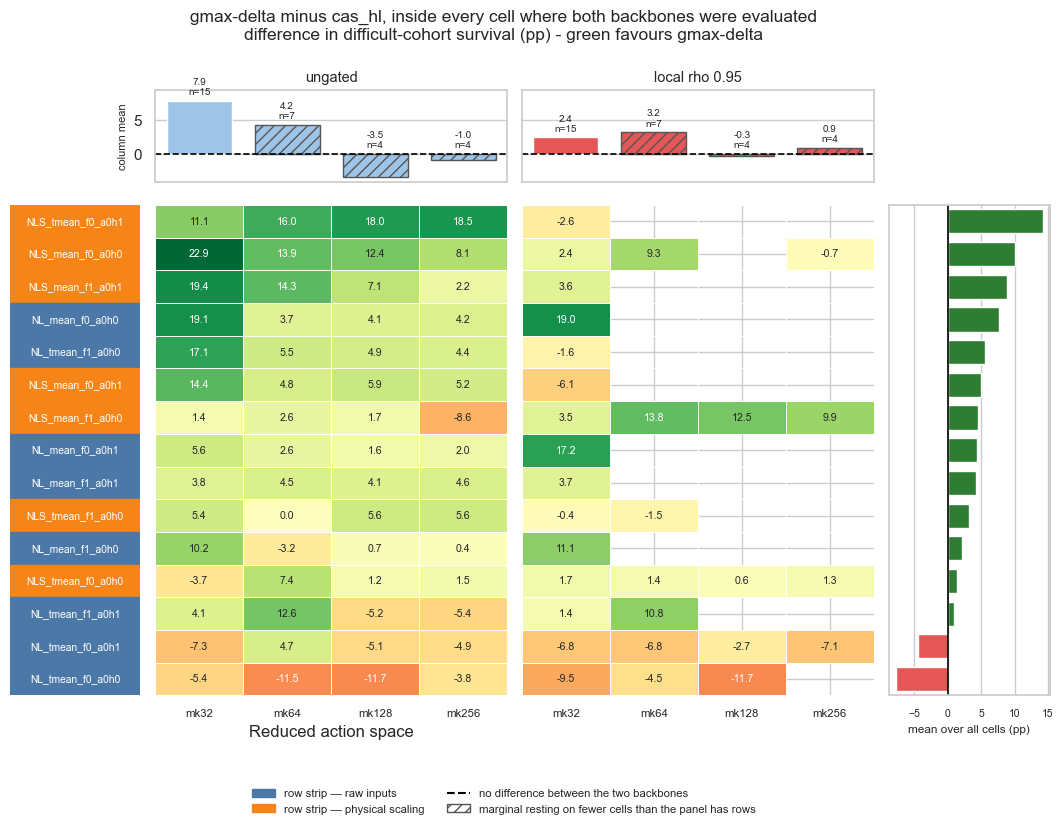

In [9]:
backbones = runs.loc[runs["arm"].isin(["bus14 zero-shot", "bus14 zero-shot (gmax-delta)"])
                     & runs["mk"].isin(GMAX_CAPS)].copy()
backbones = backbones.loc[(backbones["gate"] == "ungated") | np.isclose(backbones["rho"], 0.95)]

rows = []
for gate in ("ungated", "gated"):
    pairs = W.matched_pairs(backbones.loc[backbones["gate"] == gate], "arm",
                            ("bus14 zero-shot", "bus14 zero-shot (gmax-delta)"),
                            ["variant", "mk"], value="hard_pct")
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": "gmax-delta - cas_hl", "condition": gate, "cells": len(pairs),
                 "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "cells_favouring_gmax": int((pairs["delta"] > 0).sum())})
for arm in ("bus14 zero-shot", "bus14 zero-shot (gmax-delta)"):
    subset = backbones.loc[backbones["arm"] == arm]
    pairs = W.matched_pairs(subset, "gate", ("ungated", "gated"), ["variant", "mk"],
                            value="hard_pct")
    mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
    rows.append({"contrast": f"gate on {arm}", "condition": "ungated -> local rho 0.95",
                 "cells": len(pairs), "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                 "cells_favouring_gmax": int((pairs["delta"] > 0).sum())})
gmax_contrasts = pd.DataFrame(rows)
display(Markdown("#### Paired contrasts, matched on architecture x cap"))
display(gmax_contrasts)

gmax_delta_ungated = (
    W.matched_pairs(backbones.loc[backbones["gate"] == "ungated"], "arm",
                    ("bus14 zero-shot", "bus14 zero-shot (gmax-delta)"), ["variant", "mk"],
                    value="hard_pct")
    .pivot(index="variant", columns="mk", values="delta")
)
gmax_delta_gated = (
    W.matched_pairs(backbones.loc[backbones["gate"] == "gated"], "arm",
                    ("bus14 zero-shot", "bus14 zero-shot (gmax-delta)"), ["variant", "mk"],
                    value="hard_pct")
    .pivot(index="variant", columns="mk", values="delta")
)
gmax_delta_order = order_by_mean(gmax_delta_ungated, gmax_delta_gated)
span = float(np.nanmax(np.abs(np.concatenate([
    gmax_delta_ungated.to_numpy(dtype=float).ravel(),
    gmax_delta_gated.to_numpy(dtype=float).ravel()]))))
matrix_panel(
    {"ungated": gmax_delta_ungated.reindex(index=gmax_delta_order, columns=GMAX_CAPS),
     "local rho 0.95": gmax_delta_gated.reindex(index=gmax_delta_order, columns=GMAX_CAPS)},
    title="gmax-delta minus cas_hl, inside every cell where both backbones were evaluated",
    metric_label="difference in difficult-cohort survival (pp) - green favours gmax-delta",
    floor=0.0, floor_label="no difference between the two backbones",
    cmap="RdYlGn", vmin=-span, vmax=span,
    delta=pd.concat([gmax_delta_ungated, gmax_delta_gated]).groupby(level=0).mean().mean(axis=1),
    delta_label="mean over all cells (pp)",
    panel_colors={"ungated": GATE_COLORS["ungated"], "local rho 0.95": GATE_COLORS["gated"]},
    stem="07_gmax_minus_cas_hl",
)

## 6. The target-trained arms — everything that saw a WCCI gradient

Four routes touched the target grid: conservative MAPPO fine-tuning (mk32 and
mk64), aggressive warm-start fine-tuning (mk256), behaviour cloning on greedy
labels (mk64) and MAPPO from scratch (mk64). Between them they cover **one or
two caps and 1–16 architectures each**, and the conservative arm was evaluated
at two checkpoint selections (`best test` and `final`), which is a factor in its
own right rather than part of a model's identity.

So this page is one wide matrix rather than a pair. Each column is a fully
specified evaluation condition — route, cap, gate, checkpoint selection — and
the matching **zero-shot columns are placed on the left as the reference**. Read
it across a row: that is one architecture's whole story.

Holes are real. No marginal is drawn across these columns.

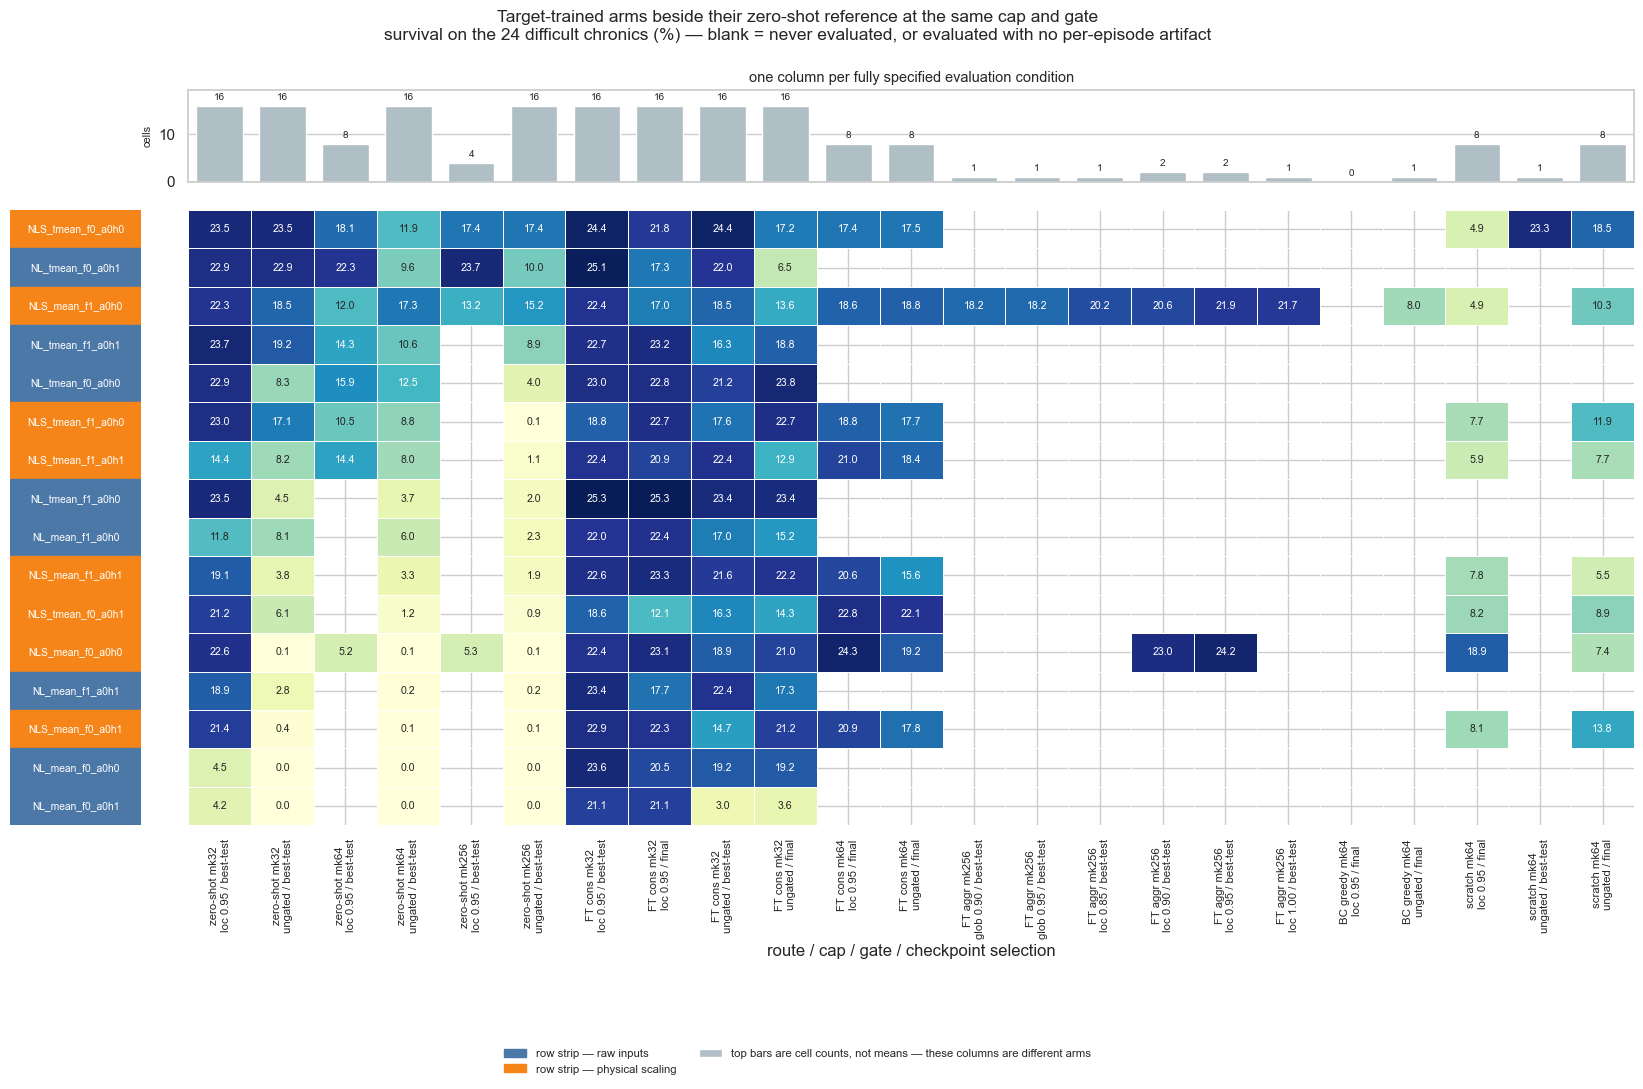

#### How thin each target-trained column really is

,arm,mk_int,gate,selection,evaluations,scored,architectures
0,MAPPO fine-tune (conservative),32,gated,best test,16,16,16
1,MAPPO fine-tune (conservative),32,gated,last,16,16,16
2,MAPPO fine-tune (conservative),32,ungated,best test,16,16,16
3,MAPPO fine-tune (conservative),32,ungated,last,16,16,16
4,MAPPO fine-tune (conservative),64,gated,last,8,8,8
5,MAPPO fine-tune (conservative),64,ungated,last,8,8,8
6,MAPPO fine-tune (aggressive),256,gated,best test,8,8,2
7,BC on greedy labels,64,gated,last,1,0,1
8,BC on greedy labels,64,ungated,last,1,1,1
9,MAPPO scratch,64,gated,last,8,8,8


In [10]:
TARGET_ROUTES = ["MAPPO fine-tune (conservative)", "MAPPO fine-tune (aggressive)",
                 "BC on greedy labels", "MAPPO scratch"]
SHORT_ROUTE = {
    "bus14 zero-shot": "zero-shot",
    "MAPPO fine-tune (conservative)": "FT cons",
    "MAPPO fine-tune (aggressive)": "FT aggr",
    "BC on greedy labels": "BC greedy",
    "MAPPO scratch": "scratch",
}
target = runs.loc[runs["arm"].isin(TARGET_ROUTES)].copy()
TARGET_CAPS = sorted({int(c) for c in target["mk"].dropna()})
reference = core.loc[core["mk"].isin(TARGET_CAPS)
                     & ((core["gate"] == "ungated") | np.isclose(core["rho"], 0.95))].copy()

board = pd.concat([reference, target], ignore_index=True)


def gate_spec(row):
    """The gate as evaluated, threshold included.

    The aggressive fine-tune arm is a *threshold screen* — two architectures at
    0.85/0.90/0.95/1.00, local and global. Labelling all of those "gated" would
    silently average a threshold search into a single cell, so the column names
    carry the scope and the value.
    """
    if row["gate"] == "ungated":
        return "ungated"
    scope = "glob" if row["heuristic"] == "global rho" else "loc"
    return f"{scope} {row['rho']:.2f}"


board["gate_label"] = board.apply(gate_spec, axis=1)
board["column"] = (
    board["arm"].astype(str).map(SHORT_ROUTE)
    + " mk" + board["mk"].astype(int).astype(str)
    + "\n" + board["gate_label"]
    + " / " + board["selection"].replace({"best test": "best-test", "last": "final"})
)
assert not board.duplicated(["variant", "column"]).any(), \
    "two evaluations share a board cell — a factor is missing from the column key"
COLUMN_ORDER = (
    board.loc[board["arm"] == "bus14 zero-shot"]
    .sort_values(["mk", "gate_label"])["column"].drop_duplicates().tolist()
    + board.loc[board["arm"] != "bus14 zero-shot"]
      .sort_values(["arm", "mk", "gate_label", "selection"])["column"].drop_duplicates().tolist()
)
TARGET_MATRIX = cell_matrix(board, "variant", "column", "hard_pct").reindex(columns=COLUMN_ORDER)
TARGET_ORDER = [v for v in CORE_ORDER if v in TARGET_MATRIX.index]
TARGET_MATRIX = TARGET_MATRIX.reindex(index=TARGET_ORDER)

matrix_panel(
    {"one column per fully specified evaluation condition": TARGET_MATRIX},
    title="Target-trained arms beside their zero-shot reference at the same cap and gate",
    metric_label=f"survival on the {N_HARD} difficult chronics (%) — blank = never evaluated, "
                 f"or evaluated with no per-episode artifact",
    floor=DN_HARD,
    column_label="route / cap / gate / checkpoint selection",
    column_fmt="{}",
    marginal="count",
    panel_colors={"one column per fully specified evaluation condition": "#B0BEC5"},
    col_width=0.64, row_height=0.40,
    stem="08_target_trained_board",
)

coverage_note = (
    board.loc[board["arm"] != "bus14 zero-shot"]
    .groupby(["arm", "mk_int", "gate", "selection"], observed=True)
    .agg(evaluations=("key", "size"), scored=("scored", "sum"),
         architectures=("variant", "nunique")).reset_index()
)
coverage_note["scored"] = coverage_note["scored"].astype(int)
display(Markdown("#### How thin each target-trained column really is"))
display(coverage_note)

### The only contrast this page supports: same architecture, same cap, same gate

Comparing a route's best cell to another route's best cell would compare the
number of attempts each was given. So every number below is a difference taken
**inside** a `(architecture, cap, gate)` cell that both routes occupy, and the
interval is a percentile bootstrap that resamples **those matched cells** — it
covers which architectures happened to be tried, and nothing else.

Every arm is held to the same gate definition here — ungated, or local rho 0.95
— so the aggressive fine-tune's four thresholds cannot turn into a per-cell
threshold search. All of them are still visible as their own columns on the
board above.

Read the sign carefully, because it does not mean the same thing in every
column. For the two fine-tuning routes and BC, the zero-shot cell **is** the
starting point, so green means the target-grid gradient improved that exact
model. **MAPPO scratch never saw bus14** — there green means the architecture
did better from a random initialisation than from the transferred weights, which
is evidence *against* the transfer being worth anything, not for it.

#### Each target-trained arm minus the zero-shot evaluation of the same architecture at the same cap and gate  
_For `MAPPO scratch` the zero-shot cell is not a starting point but a rival: a positive number there argues against transfer._

,route,condition,cells,caps,mean_pp,ci_low,ci_high,median_pp,cells_favouring_target_training
0,MAPPO fine-tune (conservative),ungated,24,mk32/mk64,11.33,8.27,14.31,11.34,21
1,MAPPO fine-tune (conservative),gated,21,mk32/mk64,5.08,2.53,7.98,2.25,17
2,MAPPO fine-tune (aggressive),gated,2,mk256,13.80,8.71,18.89,13.80,2
3,BC on greedy labels,ungated,1,mk64,-9.34,-9.34,-9.34,-9.34,0
4,MAPPO scratch,ungated,8,mk64,4.77,0.25,8.93,5.21,6
5,MAPPO scratch,gated,5,mk64,-3.56,-10.17,5.12,-7.10,1


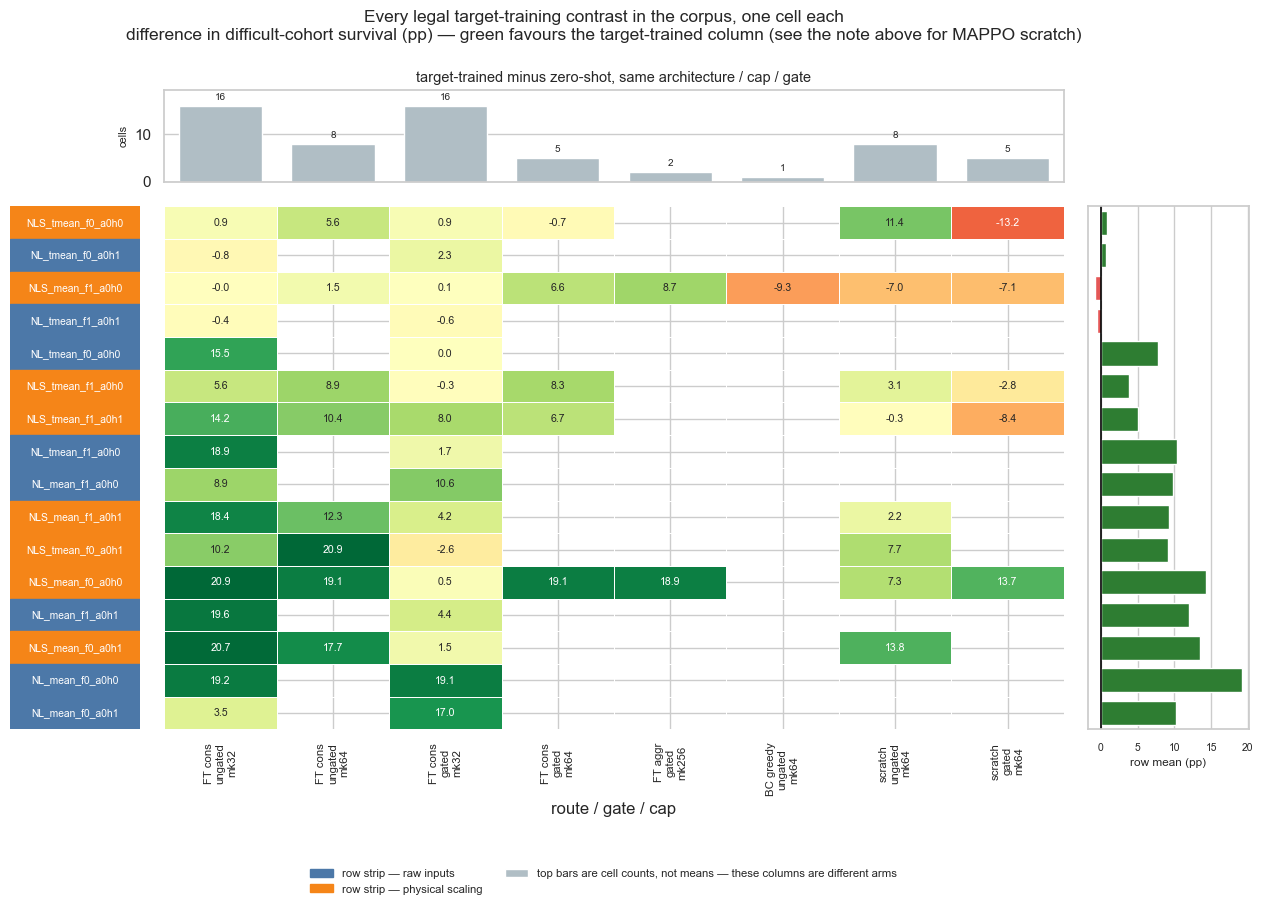

In [11]:
# `matched_pairs` resolves a cell with `max`, so the aggressive arm's four
# thresholds would become a per-cell threshold search. Hold every arm to the one
# gate definition this notebook uses everywhere else.
one_gate = target.loc[(target["gate"] == "ungated")
                      | ((target["heuristic"] == "local rho")
                         & np.isclose(target["rho"], 0.95))]

contrast_rows, delta_frames = [], {}
for route in TARGET_ROUTES:
    scope = pd.concat([reference, one_gate.loc[one_gate["arm"] == route]], ignore_index=True)
    scope = scope.loc[scope["mk"].isin(sorted({int(c) for c in
                                               one_gate.loc[one_gate["arm"] == route, "mk"].dropna()}))]
    for gate in ("ungated", "gated"):
        subset = scope.loc[scope["gate"] == gate]
        if subset["arm"].nunique() < 2:
            continue
        pairs = W.matched_pairs(subset, "arm", ("bus14 zero-shot", route),
                                ["variant", "mk"], value="hard_pct")
        if pairs.empty:
            continue
        mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
        contrast_rows.append({
            "route": route, "condition": gate, "cells": len(pairs),
            "caps": "/".join(f"mk{int(c)}" for c in sorted(set(pairs["mk"]))),
            "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
            "median_pp": float(pairs["delta"].median()),
            "cells_favouring_target_training": int((pairs["delta"] > 0).sum()),
        })
        delta_frames[f"{SHORT_ROUTE[route]}\n{gate}"] = (
            pairs.assign(mk=pairs["mk"].astype(int))
            .pivot(index="variant", columns="mk", values="delta")
        )
target_contrasts = pd.DataFrame(contrast_rows)
display(Markdown(
    "#### Each target-trained arm minus the zero-shot evaluation of the same architecture "
    "at the same cap and gate  \n"
    "_For `MAPPO scratch` the zero-shot cell is not a starting point but a rival: a positive "
    "number there argues against transfer._"
))
display(target_contrasts)

flat = pd.concat(
    [frame.rename(columns=lambda c: f"{name}\nmk{c}") for name, frame in delta_frames.items()],
    axis=1,
)
flat = flat.reindex(index=[v for v in CORE_ORDER if v in flat.index])
span = float(np.nanmax(np.abs(flat.to_numpy(dtype=float))))
matrix_panel(
    {"target-trained minus zero-shot, same architecture / cap / gate": flat},
    title="Every legal target-training contrast in the corpus, one cell each",
    metric_label="difference in difficult-cohort survival (pp) — green favours the "
                 "target-trained column (see the note above for MAPPO scratch)",
    floor=0.0,
    cmap="RdYlGn", vmin=-span, vmax=span,
    column_label="route / gate / cap",
    column_fmt="{}",
    marginal="count",
    panel_colors={"target-trained minus zero-shot, same architecture / cap / gate": "#B0BEC5"},
    col_width=1.15,
    delta=flat.mean(axis=1),
    delta_label="row mean (pp)",
    stem="09_target_minus_zero_shot",
)

## 7. The factorial behind the row labels

Every architecture name is four binary factors, and the balanced blocks let
those factors be read as marginals without any confound:

| factor | levels | token |
|---|---|---|
| input condition | raw features / physical scaling + edge-difference angle | `NL` / `NLS` |
| candidate pooling | mean / typed-mean over the touched-node embeddings | `mean` / `tmean` |
| action descriptor | static candidate features off / on | `f0` / `f1` |
| idle action | shared scorer / dedicated do-nothing head | `a0h0` / `a0h1` |

The matrix below collapses the 16 rows into the 2x2 of pooling x descriptor,
once per input condition and idle head, on each of the three complete blocks.
Each cell is the mean over that block's caps of the cells sharing those factor
levels — legal here precisely because all three are complete rectangles.

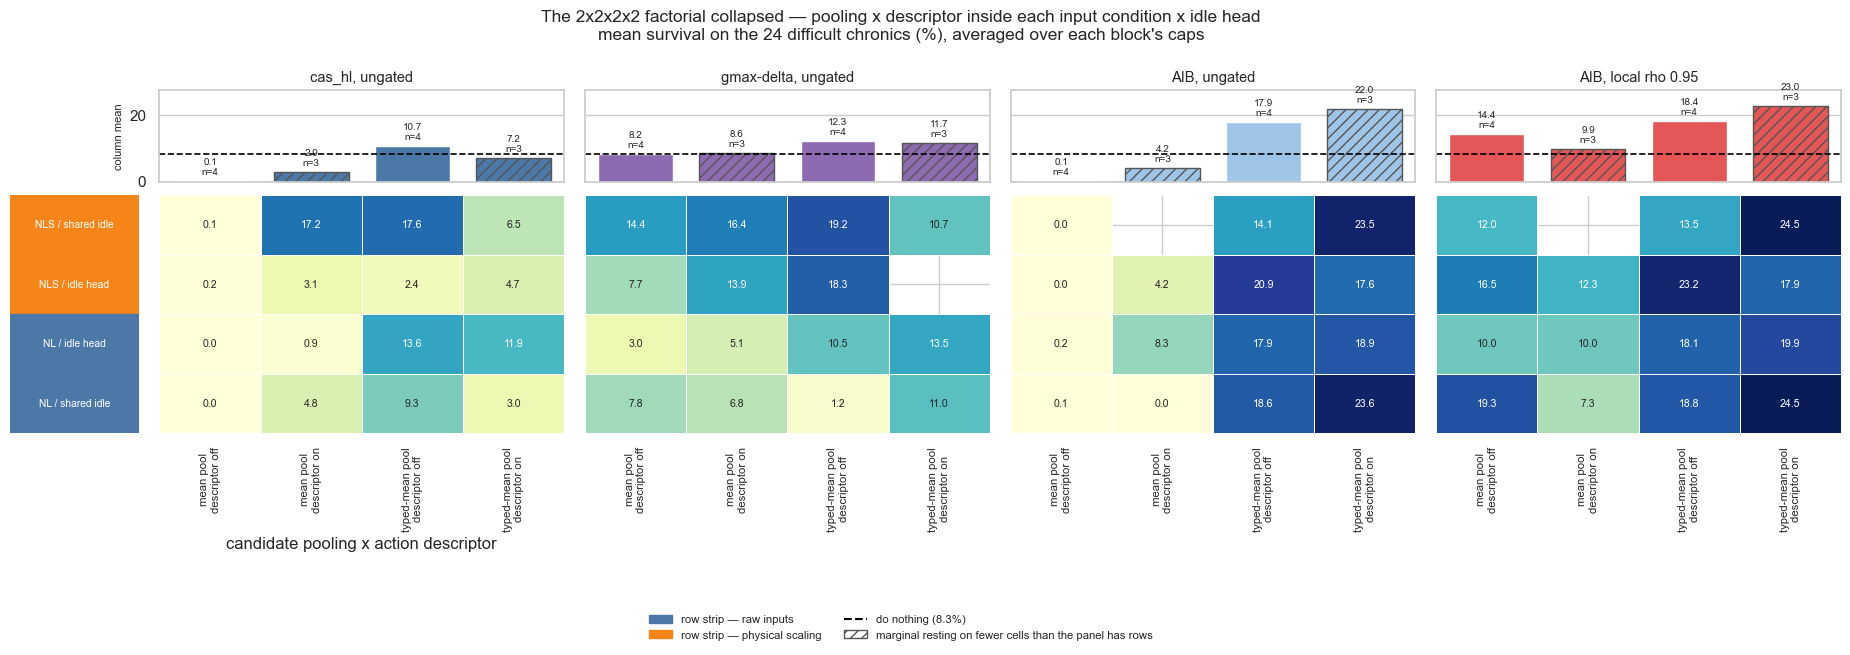

#### Each factor as a matched pair inside its own balanced block

,block,factor,contrast,cells,mean_pp,ci_low,ci_high,cells_favouring_second
0,cas_hl zero-shot ungated,scaling,physical scaling − raw inputs,32,1.01,-1.72,3.82,21
1,cas_hl zero-shot ungated,pooling,typed-mean pool − mean pool,32,5.36,2.07,8.61,22
2,cas_hl zero-shot ungated,descriptor,descriptor on − descriptor off,32,1.11,-1.74,4.03,20
3,cas_hl zero-shot ungated,idle,dedicated idle head − shared idle scorer,32,-2.72,-5.64,0.22,12
4,gmax-delta ungated,scaling,physical scaling − raw inputs,28,7.89,5.41,10.44,24
5,gmax-delta ungated,pooling,typed-mean pool − mean pool,28,3.29,0.10,6.36,18
6,gmax-delta ungated,descriptor,descriptor on − descriptor off,28,1.94,-0.66,4.51,16
7,gmax-delta ungated,idle,dedicated idle head − shared idle scorer,28,-0.70,-3.12,1.82,12
8,AIB ungated,scaling,physical scaling − raw inputs,28,-1.03,-2.25,0.09,7
9,AIB ungated,pooling,typed-mean pool − mean pool,28,16.95,14.59,18.88,27


In [12]:
def factor_matrix(frame, value, caps):
    scope = frame.loc[frame["mk"].isin(caps)]
    grid = scope.pivot_table(index=["scaling", "idle"], columns=["pooling", "descriptor"],
                             values=value, aggfunc="mean", observed=True)
    grid.index = [f"{scaling}\n{idle}" for scaling, idle in grid.index]
    grid.columns = [f"{pool}\n{descriptor}" for pool, descriptor in grid.columns]
    return grid

def SHORT_FACTOR_ROW(row):
    scaling, idle = row.split("\n")
    family = "NL" if scaling == W.SCALING_LABELS["NL"] else "NLS"
    return f"{family} / {'idle head' if idle.startswith('dedicated') else 'shared idle'}"


FACTOR_PANELS = {
    "cas_hl, ungated": factor_matrix(core_ungated, "hard_pct", CORE_CAPS),
    "gmax-delta, ungated": factor_matrix(gmax.loc[gmax["gate"] == "ungated"],
                                         "hard_pct", GMAX_CAPS),
    "AIB, ungated": factor_matrix(aib.loc[aib["gate"] == "ungated"], "hard_pct", AIB_CAPS),
    "AIB, local rho 0.95": factor_matrix(aib.loc[aib["gate"] == "gated"], "hard_pct", AIB_CAPS),
}
FACTOR_ORDER = order_by_mean(*FACTOR_PANELS.values())
FACTOR_PANELS = {k: v.reindex(index=FACTOR_ORDER) for k, v in FACTOR_PANELS.items()}

matrix_panel(
    FACTOR_PANELS,
    title="The 2x2x2x2 factorial collapsed — pooling x descriptor inside each "
          "input condition x idle head",
    metric_label=f"mean survival on the {N_HARD} difficult chronics (%), averaged over each "
                 f"block's caps",
    floor=DN_HARD,
    column_label="candidate pooling x action descriptor",
    column_fmt="{}",
    row_labels={row: SHORT_FACTOR_ROW(row) for row in FACTOR_ORDER},
    row_colors={row: FAMILY_COLORS["NL" if row.startswith(W.SCALING_LABELS["NL"]) else "NLS"]
                for row in FACTOR_ORDER},
    panel_colors={"cas_hl, ungated": "#4C78A8",
                  "gmax-delta, ungated": ARM_COLORS["bus14 zero-shot (gmax-delta)"],
                  "AIB, ungated": GATE_COLORS["ungated"],
                  "AIB, local rho 0.95": GATE_COLORS["gated"]},
    col_width=1.05, row_height=0.62,
    stem="10_factor_matrix",
)

# A factor is paired over the cells that agree on *every other* factor and the
# cap. The factor's own column must therefore be absent from `within`, or no
# cell would ever hold both levels.
FACTOR_LEVELS = {
    "scaling": list(W.SCALING_LABELS.values()),
    "pooling": list(W.POOL_LABELS.values()),
    "descriptor": list(W.DESCRIPTOR_LABELS.values()),
    "idle": list(W.IDLE_LABELS.values()),
}
FACTOR_WITHIN = {
    "scaling": ["mk", "pool", "features", "head"],
    "pooling": ["mk", "family", "features", "head"],
    "descriptor": ["mk", "family", "pool", "head"],
    "idle": ["mk", "family", "pool", "features"],
}

marginals = []
for label, block, caps in [("cas_hl zero-shot ungated", core_ungated, CORE_CAPS),
                           ("gmax-delta ungated", gmax.loc[gmax["gate"] == "ungated"], GMAX_CAPS),
                           ("AIB ungated", aib.loc[aib["gate"] == "ungated"], AIB_CAPS),
                           ("AIB local rho 0.95", aib.loc[aib["gate"] == "gated"], AIB_CAPS)]:
    scope = block.loc[block["mk"].isin(caps)]
    for factor, levels in FACTOR_LEVELS.items():
        pairs = W.matched_pairs(scope, factor, tuple(levels), FACTOR_WITHIN[factor],
                                value="hard_pct")
        if pairs.empty:
            continue
        mean_d, lo, hi = W.paired_bootstrap(pairs["delta"])
        marginals.append({"block": label, "factor": factor,
                          "contrast": f"{levels[1]} − {levels[0]}", "cells": len(pairs),
                          "mean_pp": mean_d, "ci_low": lo, "ci_high": hi,
                          "cells_favouring_second": int((pairs["delta"] > 0).sum())})
factor_contrasts = pd.DataFrame(marginals)
display(Markdown("#### Each factor as a matched pair inside its own balanced block"))
display(factor_contrasts)

## 9. Chronic by chronic: the best runs against their matching greedy oracle

Every matrix so far is a mean over the 24 difficult chronics. A mean hides which
episodes a policy actually wins, and two runs on the same score can be winning
completely different chronics. This last page unfolds that mean.

Each x-axis cluster is one difficult chronic. Inside a cluster each selected run
gets a pair of overlapping bars: the **wide grey bar** is the greedy result at
the same reduced action cap as that run, and the **narrow coloured bar** is the
run itself. A short **black segment** across the cluster is that chronic's
do-nothing survival.

The runs shown are the strongest evaluation at each of mk32, mk64 and mk256 among
the target-trained arms, the strongest AIB evaluation, and
**`gmax-delta NLS_mean_f1_a0h0`** — which is the single highest difficult-cohort
score anywhere in this corpus.

The grey bars are an empirical one-step simulation oracle over the matching
reduced action set. It is the available ceiling benchmark, not a mathematical
maximum over all possible action sequences — and because it is matched per cap,
a run at mk32 is being held to a much lower bar than a run at mk256.

In [13]:
SHOWCASE_CAPS = [32, 64, 256]
HEADLINE = ("bus14 zero-shot (gmax-delta)", "NLS_mean_f1_a0h0")


def strongest(frame):
    """Highest difficult-cohort score; an exact tie goes to the smaller cap.

    The smaller action set is the cheaper deployment and the harder benchmark to
    have beaten, so it wins a tie rather than losing one.
    """
    return frame.sort_values(["hard_pct", "mk"], ascending=[False, True]).head(1)


target_pool = runs.loc[
    runs["route"].astype(str).str.contains("fine-tune")
    & runs["mk"].isin(SHOWCASE_CAPS)
    & runs["hard_pct"].notna()
]
best_per_cap = pd.concat([strongest(group) for _, group in target_pool.groupby("mk", observed=True)])
assert set(best_per_cap["mk"].astype(int)) == set(SHOWCASE_CAPS), "a requested cap has no fine-tune"

best_aib = strongest(runs.loc[(runs["arm"] == "bus14 zero-shot + AIB") & runs["hard_pct"].notna()])
best_headline = strongest(runs.loc[
    (runs["arm"] == HEADLINE[0]) & (runs["variant"] == HEADLINE[1]) & runs["hard_pct"].notna()
])
assert len(best_headline) == 1, f"{HEADLINE[1]} has no scored {HEADLINE[0]} evaluation"

SHOWCASE_ARM = {
    "bus14 zero-shot (gmax-delta)": "gmax-delta",
    "bus14 zero-shot + AIB": "AIB",
    "MAPPO fine-tune (conservative)": "FT cons",
    "MAPPO fine-tune (aggressive)": "FT aggr",
}
showcase = pd.concat([best_per_cap, best_aib, best_headline], ignore_index=True)
showcase["label"] = [
    f"{SHOWCASE_ARM.get(str(row.arm), str(row.arm))} {row.variant} "
    f"(mk{int(row.mk)}, {'ungated' if row.gate == 'ungated' else f'rho {row.rho:.2f}'})"
    for row in showcase.itertuples()
]
assert showcase["label"].is_unique, "two selected runs share a label"
SHOWCASE_ORDER = showcase.sort_values(["arm", "mk"])["label"].tolist()
display(Markdown("#### The runs on this page, and why each was selected"))
display(showcase[["label", "arm", "variant", "mk", "gate", "rho", "selection",
                  "hard_pct", "capture_hard_pct", "hard_rescues", "overall_pct"]]
        .sort_values("hard_pct", ascending=False).round(2))

#### The runs on this page, and why each was selected

,label,arm,variant,mk,gate,rho,selection,hard_pct,capture_hard_pct,hard_rescues,overall_pct
4,"gmax-delta NLS_mean_f1_a0h0 (mk64, rho 0.95)",bus14 zero-shot (gmax-delta),NLS_mean_f1_a0h0,64,gated,0.95,best test,25.83,29.37,4.00,64.40
0,"FT cons NL_tmean_f1_a0h0 (mk32, rho 0.95)",MAPPO fine-tune (conservative),NL_tmean_f1_a0h0,32,gated,0.95,best test,25.27,68.33,4.00,64.13
3,"AIB NL_tmean_f1_a0h0 (mk32, rho 0.95)",bus14 zero-shot + AIB,NL_tmean_f1_a0h0,32,gated,0.95,best test,25.12,67.75,4.00,64.06
1,"FT cons NLS_mean_f0_a0h0 (mk64, rho 0.95)",MAPPO fine-tune (conservative),NLS_mean_f0_a0h0,64,gated,0.95,last,24.27,26.75,4.00,63.65
2,"FT aggr NLS_mean_f0_a0h0 (mk256, rho 0.95)",MAPPO fine-tune (aggressive),NLS_mean_f0_a0h0,256,gated,0.95,best test,24.15,18.26,4.00,63.59


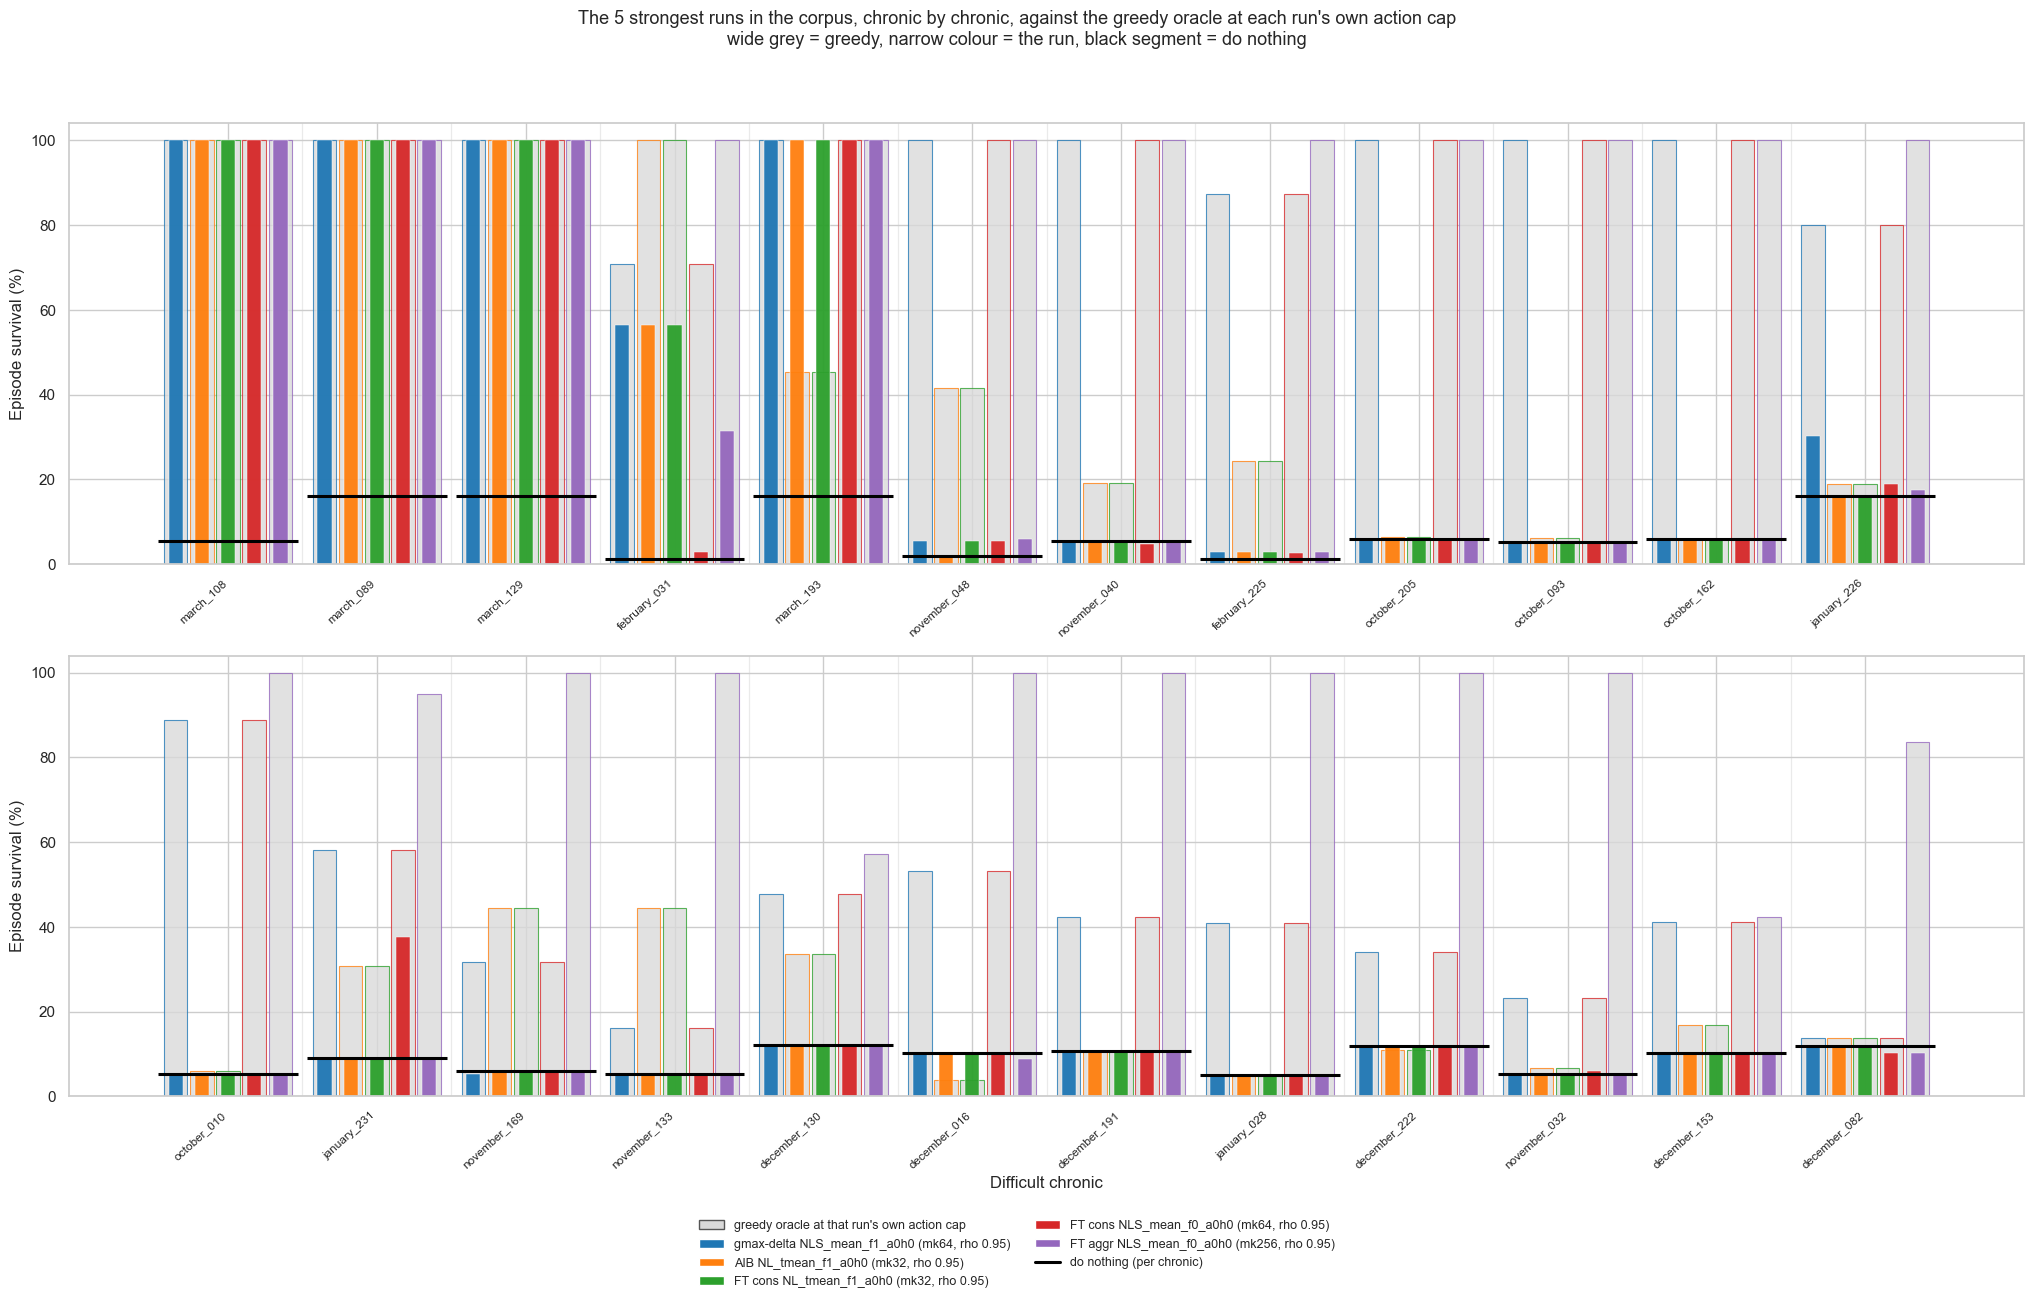

#### Each run against its own matching oracle, over the 24 difficult chronics

,label,mk,model_hard_pct,greedy_hard_pct,mean_gap_pp,chronics_beating_greedy,chronics_tied,full_survivals
0,"gmax-delta NLS_mean_f1_a0h0 (mk64, rho 0.95)",64,25.83,67.88,-42.05,0,4,4
1,"FT cons NL_tmean_f1_a0h0 (mk32, rho 0.95)",32,25.27,33.11,-7.85,6,3,4
2,"AIB NL_tmean_f1_a0h0 (mk32, rho 0.95)",32,25.12,33.11,-7.99,6,3,4
3,"FT cons NLS_mean_f0_a0h0 (mk64, rho 0.95)",64,24.27,67.88,-43.62,0,4,4
4,"FT aggr NLS_mean_f0_a0h0 (mk256, rho 0.95)",256,24.15,94.92,-70.77,0,4,4


In [14]:
showcase_episodes = (
    data.episodes.loc[data.episodes["key"].isin(showcase["key"]) & data.episodes["is_hard"]]
    .merge(showcase[["key", "variant", "mk", "arm", "label"]], on="key", how="inner",
           validate="many_to_one")
)
greedy_match = (
    data.greedy_episodes.loc[
        data.greedy_episodes["mk"].isin(showcase["mk"].unique()) & data.greedy_episodes["is_hard"],
        ["mk", "greedy_chronic_fingerprint", "greedy_survival"],
    ].rename(columns={"greedy_chronic_fingerprint": "chronic_fingerprint"})
)
assert not greedy_match.duplicated(["mk", "chronic_fingerprint"]).any()
showcase_chronic = showcase_episodes.merge(
    greedy_match, on=["mk", "chronic_fingerprint"], how="left", validate="many_to_one"
)
assert showcase_chronic["greedy_survival"].notna().all(), "a matching greedy chronic is missing"
assert len(showcase_chronic) == N_HARD * len(showcase)
showcase_chronic["model_pct"] = 100 * showcase_chronic["survival"]
showcase_chronic["greedy_pct"] = 100 * showcase_chronic["greedy_survival"]
showcase_chronic["gap_to_greedy_pp"] = (
    showcase_chronic["model_pct"] - showcase_chronic["greedy_pct"]
)

chronic_order = (
    showcase_chronic.groupby("chronic_name", observed=True)["greedy_pct"].mean()
    .sort_values(ascending=False).index.tolist()
)
showcase_colors = dict(zip(SHOWCASE_ORDER, sns.color_palette("tab10", len(SHOWCASE_ORDER))))
slot = 0.88 / len(SHOWCASE_ORDER)
offsets = (np.arange(len(SHOWCASE_ORDER)) - (len(SHOWCASE_ORDER) - 1) / 2) * slot

panels = [chronic_order[start:start + 12] for start in range(0, len(chronic_order), 12)]
fig, axes = plt.subplots(len(panels), 1, figsize=(20.5, 5.8 * len(panels)),
                         sharey=True, squeeze=False)
for ax, panel in zip(axes.ravel(), panels):
    centres = np.arange(len(panel), dtype=float)
    for index, label in enumerate(SHOWCASE_ORDER):
        rows = (showcase_chronic.loc[showcase_chronic["label"] == label]
                .set_index("chronic_name").reindex(panel))
        x = centres + offsets[index]
        # The matching greedy oracle sits behind its own model: same chronic,
        # same action cap. Comparing a model to another model's grey bar is
        # comparing two different ceilings.
        ax.bar(x, rows["greedy_pct"], width=slot * 0.90, color="#D9D9D9",
               edgecolor=showcase_colors[label], linewidth=0.8, alpha=0.78, zorder=1)
        ax.bar(x, rows["model_pct"], width=slot * 0.54, color=showcase_colors[label],
               edgecolor="white", linewidth=0.35, alpha=0.95, zorder=2)
    do_nothing = (showcase_chronic.drop_duplicates("chronic_name")
                  .set_index("chronic_name").reindex(panel))
    for centre, value in zip(centres, 100 * do_nothing["dn_survival"]):
        ax.hlines(value, centre - 0.47, centre + 0.47, color="black", linewidth=2.2, zorder=4)
    for boundary in centres[:-1] + 0.5:
        ax.axvline(boundary, color="#EAEAEA", linewidth=0.9, zorder=0)
    ax.set_xticks(centres, [name.replace("Scenario_", "") for name in panel],
                  rotation=42, ha="right", fontsize=8.5)
    ax.set_ylim(0, 104)
    ax.set_ylabel("Episode survival (%)")
axes.ravel()[-1].set_xlabel("Difficult chronic")

handles = [Patch(facecolor="#D9D9D9", edgecolor="#555555",
                 label="greedy oracle at that run's own action cap")]
handles += [Patch(facecolor=showcase_colors[label], label=label) for label in SHOWCASE_ORDER]
handles += [Line2D([0], [0], color="black", linewidth=2.2, label="do nothing (per chronic)")]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2,
           fontsize=9, frameon=False)
fig.suptitle(
    f"The {len(SHOWCASE_ORDER)} strongest runs in the corpus, chronic by chronic, against the "
    f"greedy oracle at each run's own action cap\n"
    f"wide grey = greedy, narrow colour = the run, black segment = do nothing",
    y=1.0, va="bottom", fontsize=13,
)
fig.tight_layout()
save_figure(fig, "11_showcase_hard_chronic_vs_greedy")
plt.show()

showcase_summary = (
    showcase_chronic.groupby(["label", "mk"], observed=True)
    .agg(model_hard_pct=("model_pct", "mean"),
         greedy_hard_pct=("greedy_pct", "mean"),
         mean_gap_pp=("gap_to_greedy_pp", "mean"),
         chronics_beating_greedy=("gap_to_greedy_pp", lambda v: int((v > 1e-9).sum())),
         chronics_tied=("gap_to_greedy_pp", lambda v: int(np.isclose(v, 0).sum())),
         full_survivals=("full_survival", "sum"))
    .sort_values("model_hard_pct", ascending=False).reset_index()
)
display(Markdown("#### Each run against its own matching oracle, over the 24 difficult chronics"))
display(showcase_summary.round(2))

## 10. What these matrices cannot tell you

A reference sheet is only useful if its limits are on the same page as its
numbers.

1. **One seed everywhere.** Every cell is `s0`. Nothing here separates an
   architecture effect from training-seed noise, and the paired bootstrap
   intervals resample **chronics only** — they do not cover seed variance.
2. **The caps and thresholds were chosen on this same set.** mk512/mk1024 and
   the rho grid were added because earlier results pointed at them, so the best
   cells on these pages are optimistic by an unmeasured amount.
3. **The three complete blocks are three different training recipes.** `cas_hl`,
   `gmax-delta` and AIB are each internally balanced, so each carries its own
   marginals — but a marginal from one is not a measurement of another. Only the
   matched-cell contrasts in §4 and §5 compare them.
4. **The greedy oracle is empirical, not a maximum, and it is matched per cap.** `capture_hard_pct` in §3
   is scaled by a one-step simulation oracle over the same reduced action set —
   the available benchmark, not a bound over all action sequences.
5. **The gated panels are a threshold screen, not a gate.** §2 shows local-rho
   0.95 only; 0.85, 0.90 and 1.00 exist at some cells and are deliberately
   excluded rather than folded in with a `max`, which would have made the gate
   look better than any single deployable threshold is.
6. **64 artifacts were found by tail-matching, not at their declared path.**
   Each was verified against its own JSON before use, but the path mismatch
   means the result files and the artifact tree disagree about where things
   live, and a future sync could reintroduce ambiguity.

The experiments that would close these: a second and third seed on the ungated
`cas_hl` block; a held-out threshold set for the rho gate; and a re-run of the
one `dangerous_graph_bc` evaluation whose artifact does not match its JSON.

In [15]:
ledger = pd.DataFrame([
    {"limit": "single seed (s0) in every cell", "affects": "all matrices",
     "evaluations": int(len(runs))},
    {"limit": "artifact found by tail-match, not at its declared path",
     "affects": "verified against its own JSON before use",
     "evaluations": int(len(data.relocated_artifacts))},
    {"limit": "gate shown at one threshold; other rho values excluded",
     "affects": "sections 2, 5, 6",
     "evaluations": int(((runs["gate"] == "gated") & ~np.isclose(runs["rho"], 0.95)).sum())},
    {"limit": "arm exists at a single cap — no cap marginal possible",
     "affects": "conservative/aggressive fine-tune, BC, scratch",
     "evaluations": int(runs.loc[runs["arm"].isin(TARGET_ROUTES)].shape[0])},
    {"limit": "artifact rejected: episode CSV does not reproduce its own JSON",
     "affects": "excluded from every scored matrix",
     "evaluations": int(len(data.rejected_artifacts))},
])
display(Markdown("#### Numeric ledger of the counter-evidence"))
display(ledger)
if len(data.rejected_artifacts):
    display(Markdown("#### Evaluations whose artifact was refused by the loader"))
    display(data.rejected_artifacts)

balanced = pd.DataFrame([
    {"block": "cas_hl zero-shot, ungated", "architectures": len(CORE_ORDER),
     "caps": len(CORE_CAPS), "cells": len(CORE_ORDER) * len(CORE_CAPS),
     "complete": bool(CORE_HARD["ungated"].notna().all().all()),
     "metric": "hard_pct"},
    {"block": "AIB, both gates", "architectures": len(AIB_ORDER), "caps": len(AIB_CAPS),
     "cells": 2 * len(AIB_ORDER) * len(AIB_CAPS),
     "complete": bool(all(m.notna().all().all() for m in AIB_HARD.values())),
     "metric": "hard_pct"},
    {"block": "gmax-delta, both gates", "architectures": len(GMAX_ORDER), "caps": len(GMAX_CAPS),
     "cells": 2 * len(GMAX_ORDER) * len(GMAX_CAPS),
     "complete": bool(all(m.notna().all().all() for m in GMAX_HARD.values())),
     "metric": "hard_pct"},
])
display(Markdown("#### The blocks that are complete rectangles — the only places a marginal is safe"))
display(balanced)

#### Numeric ledger of the counter-evidence

,limit,affects,evaluations
0,single seed (s0) in every cell,all matrices,497
1,"artifact found by tail-match, not at its decla...",verified against its own JSON before use,64
2,gate shown at one threshold; other rho values ...,"sections 2, 5, 6",27
3,arm exists at a single cap — no cap marginal p...,"conservative/aggressive fine-tune, BC, scratch",107
4,artifact rejected: episode CSV does not reprod...,excluded from every scored matrix,1


#### Evaluations whose artifact was refused by the loader

,key,episode_csv
0,dangerous_graph_bc/bcg_direct_bus14_cons1496_e...,/Users/corentinplumet/Documents/RL_Marl2grid/T...


#### The blocks that are complete rectangles — the only places a marginal is safe

,block,architectures,caps,cells,complete,metric
0,"cas_hl zero-shot, ungated",16,4,64,True,hard_pct
1,"AIB, both gates",15,4,120,True,hard_pct
2,"gmax-delta, both gates",15,4,120,True,hard_pct


## 11. Every matrix on this page, as a file

Each figure is written as a PNG and each matrix as a CSV in the same directory,
so a number on any page can be traced back to the cell it came from.

In [16]:
exports = {
    "inventory_by_arm_cap_gate.csv": inventory,
    "core_hard_ungated.csv": CORE_HARD["ungated"].reset_index(),
    "core_hard_gated_rho095.csv": CORE_HARD["local rho 0.95"].reset_index(),
    "core_capture_ungated.csv": CORE_CAPTURE["ungated"].reset_index(),
    "core_gate_pairs.csv": gate_pairs,
    "aib_hard_ungated.csv": AIB_HARD["ungated"].reset_index(),
    "aib_hard_gated_rho095.csv": AIB_HARD["local rho 0.95"].reset_index(),
    "aib_minus_zero_shot.csv": aib_delta_matrix.reset_index(),
    "aib_contrasts.csv": aib_contrasts,
    "gmax_hard_ungated.csv": GMAX_HARD["ungated"].reset_index(),
    "gmax_hard_gated_rho095.csv": GMAX_HARD["local rho 0.95"].reset_index(),
    "gmax_minus_cas_hl.csv": gmax_delta_ungated.reset_index(),
    "gmax_contrasts.csv": gmax_contrasts,
    "target_trained_board.csv": TARGET_MATRIX.reset_index(),
    "target_trained_coverage.csv": coverage_note,
    "target_minus_zero_shot.csv": flat.reset_index(),
    "target_contrasts.csv": target_contrasts,
    "factor_contrasts.csv": factor_contrasts,
    "ledger.csv": ledger,
    "showcase_runs.csv": showcase.drop(columns=["episode_csv", "action_summary_json"],
                                       errors="ignore"),
    "showcase_by_chronic.csv": showcase_chronic[[
        "label", "arm", "variant", "mk", "chronic_name", "model_pct", "greedy_pct",
        "gap_to_greedy_pp", "dn_survival", "full_survival",
    ]],
    "showcase_summary.csv": showcase_summary,
    "balanced_blocks.csv": balanced,
    "all_runs.csv": runs[[
        "key", "arm", "route", "group", "run", "variant", "family", "pool", "features", "head",
        "mk", "gate", "heuristic", "rho", "selection", "checkpoint_step",
        "overall_pct", "hard_pct", "capture_hard_pct", "hard_rescues", "hard_wins",
        "hard_losses", "easy_kept", "scored",
    ]].sort_values(["arm", "mk", "gate", "variant"]),
}
for name, table in exports.items():
    table.to_csv(EXPORT_DIR / name, index=False)
print(f"{len(exports)} tables + 11 figures written to:\n{EXPORT_DIR}")

24 tables + 11 figures written to:
/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/wcci_full_matrix_report
